In [132]:
#### --1--
# Load both datasets and preview them
import pandas as pd

meta_df = pd.read_csv('Zomato Restaurant names and Metadata.csv', encoding='utf-8')
reviews_df = pd.read_csv('Zomato Restaurant reviews.csv', encoding='utf-8')

print("--- Restaurant Metadata ---")
print(meta_df.head())
print("\Shape: " + str(meta_df.shape))
print("__"*30)
print("\
--- Restaurant Reviews ---")
print(reviews_df.head())
print("\Shape: " + str(reviews_df.shape))


--- Restaurant Metadata ---
                             Name   
0                 Beyond Flavours  \
1                        Paradise   
2                        Flechazo   
3  Shah Ghouse Hotel & Restaurant   
4      Over The Moon Brew Company   

                                               Links   Cost   
0  https://www.zomato.com/hyderabad/beyond-flavou...    800  \
1  https://www.zomato.com/hyderabad/paradise-gach...    800   
2  https://www.zomato.com/hyderabad/flechazo-gach...  1,300   
3  https://www.zomato.com/hyderabad/shah-ghouse-h...    800   
4  https://www.zomato.com/hyderabad/over-the-moon...  1,200   

                                         Collections   
0  Food Hygiene Rated Restaurants in Hyderabad, C...  \
1                                Hyderabad's Hottest   
2                 Great Buffets, Hyderabad's Hottest   
3                             Late Night Restaurants   
4  Best Bars & Pubs, Food Hygiene Rated Restauran...   

                                 

In [133]:
#### --2--
# Quick, efficient EDA: basic profiling, missingness, duplicates, and key distributions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")


In [134]:
#### --3--
# Missingness
# meta_df["Collections"] is missing for about 51% of rows (biggest gap).
# meta_df["Timings"] is ~1% missing.
# reviews_df has very low missingness (~0.4% in a few columns).

meta_missing = meta_df.isna().mean().sort_values(ascending=False)
reviews_missing = reviews_df.isna().mean().sort_values(ascending=False)

print(meta_missing)
print(reviews_missing)


Collections    0.514286
Timings        0.009524
Name           0.000000
Links          0.000000
Cost           0.000000
Cuisines       0.000000
dtype: float64
Review        0.0045
Reviewer      0.0038
Rating        0.0038
Metadata      0.0038
Time          0.0038
Restaurant    0.0000
Pictures      0.0000
dtype: float64


In [135]:
#### --4--
# Duplicates
# meta_df has 0 duplicate rows.
# reviews_df has 36 duplicate rows (worth dropping early).

print(meta_df.duplicated().sum())
print(reviews_df.duplicated().sum())


0
36


In [136]:
#### --5--
# Standardize key join fields early
# Clean numeric rating for quick plots
reviews_df["Rating_num"] = pd.to_numeric(reviews_df["Rating"], errors="coerce")


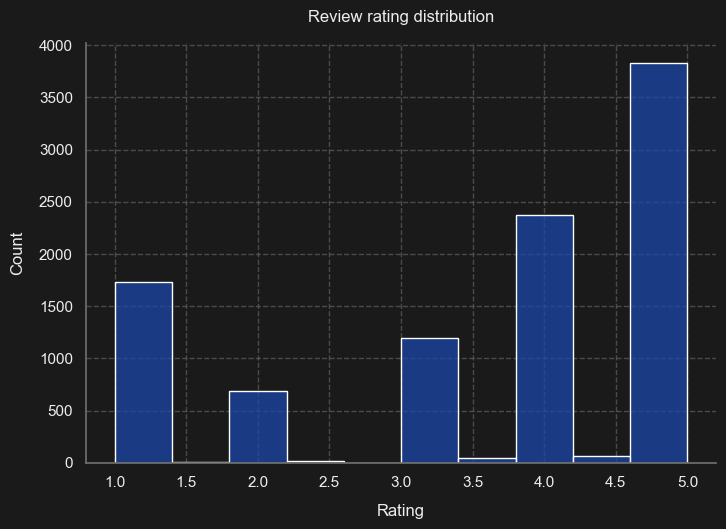

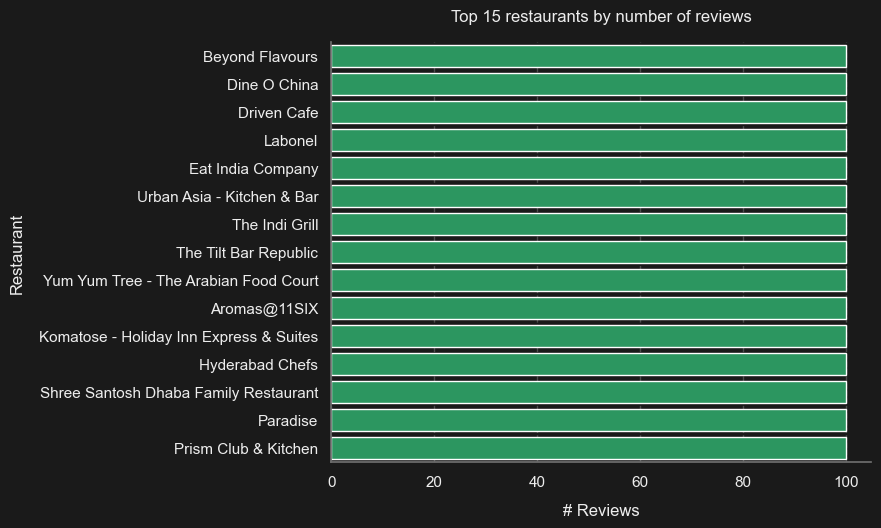

In [137]:
#### --6--
plt.figure(figsize=(9,6))
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
plt.gcf().set_facecolor('#1A1A1A')
ax = plt.gca()
ax.set_facecolor('#1A1A1A')
ax.grid(True, color='#6D6D6D', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6D6D6D')
ax.spines['bottom'].set_color('#6D6D6D')
ax.tick_params(colors='#EDEDED')
ax.xaxis.label.set_color('#EDEDED')
ax.yaxis.label.set_color('#EDEDED')
ax.title.set_color('#EDEDED')

sns.histplot(reviews_df["Rating_num"].dropna(), bins=10, color="#1B47A7")
plt.title("Review rating distribution", pad=15)
plt.xlabel("Rating", labelpad=10)
plt.ylabel("Count", labelpad=10)
plt.show()

# Top restaurants by review count
top_rest = reviews_df["Restaurant"].value_counts().head(15)
plt.figure(figsize=(9,6))
plt.subplots_adjust(left=0.25, right=0.85, top=0.85, bottom=0.15)
plt.gcf().set_facecolor('#1A1A1A')
ax = plt.gca()
ax.set_facecolor('#1A1A1A')
ax.grid(True, axis='x', color='#6D6D6D', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6D6D6D')
ax.spines['bottom'].set_color('#6D6D6D')
ax.tick_params(colors='#EDEDED')
ax.xaxis.label.set_color('#EDEDED')
ax.yaxis.label.set_color('#EDEDED')
ax.title.set_color('#EDEDED')

sns.barplot(x=top_rest.values, y=top_rest.index, color="#1BA75F")
plt.title("Top 15 restaurants by number of reviews", pad=15)
plt.xlabel("# Reviews", labelpad=10)
plt.ylabel("Restaurant", labelpad=10)
plt.show()


In [138]:
#### --7--
# Update the standardization to Title Case (instead of lowercase) and show before/after
import re

meta_cols_before = list(meta_df.columns)
#print( meta_cols_before)
reviews_cols_before = list(reviews_df.columns)

def standardize_columns_title(col_list):
    # Strip, replace non-alphanum with underscore, collapse underscores, then Title Case words
    new_cols = []
    for col_name in col_list:
        col_clean = str(col_name).strip()
        #print( col_clean)
        col_clean = re.sub(r"[^0-9A-Za-z]+", "_", col_clean)
        #print( col_clean)
        col_clean = re.sub(r"_+", "_", col_clean).strip("_")
        col_clean = col_clean.replace("_", " ").title().replace(" ", "_")
        new_cols.append(col_clean)
    return new_cols

meta_df.columns = standardize_columns_title(meta_df.columns)
reviews_df.columns = standardize_columns_title(reviews_df.columns)

meta_cols_after = list(meta_df.columns)
reviews_cols_after = list(reviews_df.columns)

print(meta_cols_before)
print(meta_cols_after)
print(reviews_cols_before)
print(reviews_cols_after)

print(meta_df.head())
print(reviews_df.head())


['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']
['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings']
['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Rating_num']
['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Rating_Num']
                             Name   
0                 Beyond Flavours  \
1                        Paradise   
2                        Flechazo   
3  Shah Ghouse Hotel & Restaurant   
4      Over The Moon Brew Company   

                                               Links   Cost   
0  https://www.zomato.com/hyderabad/beyond-flavou...    800  \
1  https://www.zomato.com/hyderabad/paradise-gach...    800   
2  https://www.zomato.com/hyderabad/flechazo-gach...  1,300   
3  https://www.zomato.com/hyderabad/shah-ghouse-h...    800   
4  https://www.zomato.com/hyderabad/over-the-moon...  1,200   

                                         Collections   
0  Food Hygiene Rated Restau

In [139]:
#### --8--
# Inspect current dtypes, parse/clean key columns, and show before/after summaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# print(meta_df.dtypes)
# print(reviews_df.dtypes)

# --- Meta: Cost to numeric ---
meta_df['Cost'] = pd.to_numeric(meta_df['Cost'], errors='coerce')

# # --- Reviews: Rating_Num already exists; ensure numeric and keep a consistent name ---
# if 'Rating_Num' in reviews_df.columns:
#     reviews_df['Rating_Num'] = pd.to_numeric(reviews_df['Rating_Num'], errors='coerce')
# else:
#     reviews_df['Rating_Num'] = pd.to_numeric(reviews_df['Rating'], errors='coerce')

# --- Reviews: Time to datetime (best-effort) YYYY-MM-DD HH:MM:SS ---
if 'Time' in reviews_df.columns:
    reviews_df['Time_Parsed'] = pd.to_datetime(reviews_df['Time'], errors='coerce')
# print("*"*50)
# print( reviews_df['Time_Parsed'])

# --- Reviews: Metadata like "1 Review , 2 Followers" -> extract numbers ---
if 'Metadata' in reviews_df.columns:
    meta_str = reviews_df['Metadata'].astype(str)
    reviews_df['Reviewer_Review_Count'] = pd.to_numeric(meta_str.str.extract(r'(\d+)\s*Review', expand=False), errors='coerce')
    reviews_df['Reviewer_Follower_Count'] = pd.to_numeric(meta_str.str.extract(r'(\d+)\s*Follower', expand=False), errors='coerce')

print("_"*50)    
print(meta_df.dtypes)
print(reviews_df.dtypes)
print("_"*50)

print(meta_df[['Cost']].describe())
print(reviews_df[['Rating_Num']].describe())
print("_"*50)

# Quick check: how many parsed times
if 'Time_Parsed' in reviews_df.columns:
    print("Non-missing in Time_Parsed" , reviews_df['Time_Parsed'].notna().mean())  # .notna()-Check non-missing values

    
print("_"*50) 
print(meta_df.head())
print("_"*50) 
print(reviews_df.head())
    

__________________________________________________
Name            object
Links           object
Cost           float64
Collections     object
Cuisines        object
Timings         object
dtype: object
Restaurant                         object
Reviewer                           object
Review                             object
Rating                             object
Metadata                           object
Time                               object
Pictures                            int64
Rating_Num                        float64
Time_Parsed                datetime64[ns]
Reviewer_Review_Count             float64
Reviewer_Follower_Count           float64
dtype: object
__________________________________________________
             Cost
count   67.000000
mean   543.283582
std    194.409659
min    150.000000
25%    400.000000
50%    550.000000
75%    700.000000
max    900.000000
        Rating_Num
count  9961.000000
mean      3.601044
std       1.483461
min       1.000000
25%       3.0

In [140]:
#### --9--
# Summarize missingness and outliers for key numeric fields (Cost, Rating_Num)
import numpy as np
import pandas as pd

meta_missing = meta_df.isna().mean().sort_values(ascending=False)
reviews_missing = reviews_df.isna().mean().sort_values(ascending=False)

print(meta_missing.head(10))
print(reviews_missing.head(10))

# Numeric summaries
if 'Cost' in meta_df.columns:
    print(meta_df['Cost'].describe())

if 'Rating_Num' in reviews_df.columns:
    print(reviews_df['Rating_Num'].describe())

# IQR-based outlier counts
outlier_stats = {}
if 'Cost' in meta_df.columns:
    cost_vals = meta_df['Cost'].dropna()
    q1 = cost_vals.quantile(0.25)
    q3 = cost_vals.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    outlier_stats['Cost_outlier_rate'] = ((cost_vals < lo) | (cost_vals > hi)).mean()
    outlier_stats['Cost_lo'] = lo
    outlier_stats['Cost_hi'] = hi

if 'Rating_Num' in reviews_df.columns:
    rating_vals = reviews_df['Rating_Num'].dropna()
    q1 = rating_vals.quantile(0.25)
    q3 = rating_vals.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    outlier_stats['Rating_outlier_rate'] = ((rating_vals < lo) | (rating_vals > hi)).mean()
    outlier_stats['Rating_lo'] = lo
    outlier_stats['Rating_hi'] = hi

print(pd.Series(outlier_stats))


Collections    0.514286
Cost           0.361905
Timings        0.009524
Name           0.000000
Links          0.000000
Cuisines       0.000000
dtype: float64
Reviewer_Follower_Count    0.1616
Review                     0.0045
Reviewer_Review_Count      0.0044
Rating_Num                 0.0039
Reviewer                   0.0038
Rating                     0.0038
Metadata                   0.0038
Time                       0.0038
Time_Parsed                0.0038
Restaurant                 0.0000
dtype: float64
count     67.000000
mean     543.283582
std      194.409659
min      150.000000
25%      400.000000
50%      550.000000
75%      700.000000
max      900.000000
Name: Cost, dtype: float64
count    9961.000000
mean        3.601044
std         1.483461
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Rating_Num, dtype: float64
Cost_outlier_rate         0.0
Cost_lo                 -50.0
Cost_hi                1150.0
Rating_o

In [141]:
#### --10--
# Create standardized open/close time columns for Morning/Afternoon/Evening/Night from meta_df['Timings']
# Assumptions to move forward
# - 'Timings' is a free-text field that may contain day ranges and one or more time ranges
# - We extract all time ranges like "10 AM to 11 PM" from the string
# - We normalize tokens Noon=12 PM, Midnight=12 AM, Morning=AM
# - We then map each extracted range into one of 4 buckets by its start time

import re
import numpy as np
import pandas as pd

if 'Timings' not in meta_df.columns:
    raise ValueError('meta_df must contain a Timings column')

meta_df['Timings_Clean'] = meta_df['Timings'].astype(str)

# --- helpers ---

def _normalize_time_tokens(t_str):
    if t_str is None:
        return ''
    t_val = str(t_str).strip()
    t_val = re.sub(r'\s+', ' ', t_val)
    t_val = t_val.replace('.', '')
    # normalize common words
    t_val = re.sub(r'(?i)noon', '12 PM', t_val)
    t_val = re.sub(r'(?i)midnight', '12 AM', t_val)
    # if someone wrote 'morning' near a time, treat as AM
    t_val = re.sub(r'(?i)\morning\', 'AM', t_val)
    return t_val


def _parse_time_to_minutes(t_str):
    if t_str is None:
        return np.nan
    t_val = _normalize_time_tokens(t_str)
    t_val = t_val.strip().upper()

    # Accept formats like 7 PM, 7:30 PM, 07:30PM
    match_obj = re.search(r'(\d{1,2})(?::(\d{2}))?\s*(AM|PM)', t_val)
    if not match_obj:
        return np.nan
    hour_val = int(match_obj.group(1))
    min_val = int(match_obj.group(2)) if match_obj.group(2) is not None else 0
    ampm_val = match_obj.group(3)

    # 12 AM -> 0, 12 PM -> 12
    if hour_val == 12:
        hour_val = 0 if ampm_val == 'AM' else 12
    else:
        if ampm_val == 'PM':
            hour_val = hour_val + 12

    return hour_val * 60 + min_val


def _minutes_to_ampm(minutes_val):
    if minutes_val is None or (isinstance(minutes_val, float) and np.isnan(minutes_val)):
        return np.nan
    minutes_val = int(minutes_val)
    hour24_val = minutes_val // 60
    min_val = minutes_val % 60
    ampm_val = 'AM' if hour24_val < 12 else 'PM'
    hour12_val = hour24_val % 12
    if hour12_val == 0:
        hour12_val = 12
    return str(hour12_val) + ':' + str(min_val).zfill(2) + ' ' + ampm_val


def _extract_ranges(timings_str):
    # Return list of tuples (start_minutes, end_minutes)
    if timings_str is None:
        return []
    txt_val = _normalize_time_tokens(timings_str)

    # Normalize separators
    txt_val = re.sub(r'(?i)\to\', ' to ', txt_val)
    txt_val = re.sub(r'\s+', ' ', txt_val)

    # Pattern for time range: <time> to <time>
    time_pat = r'(\d{1,2}(?::\d{2})?\s*(?:AM|PM))'
    range_pat = re.compile(time_pat + r'\s*to\s*' + time_pat, flags=re.IGNORECASE)

    ranges_out = []
    for match_obj in range_pat.finditer(txt_val):
        start_str = match_obj.group(1)
        end_str = match_obj.group(2)
        start_min = _parse_time_to_minutes(start_str)
        end_min = _parse_time_to_minutes(end_str)
        if not (isinstance(start_min, float) and np.isnan(start_min)) and not (isinstance(end_min, float) and np.isnan(end_min)):
            ranges_out.append((start_min, end_min))
    return ranges_out


def _bucket_for_start(start_min):
    # Buckets by start time per your rules
    # Night: 12 AM - 6 AM
    # Morning: 6 AM - 12 PM
    # Afternoon: 12 PM - 4 PM
    # Evening: 4 PM - 12 AM
    if start_min is None or (isinstance(start_min, float) and np.isnan(start_min)):
        return None
    if 0 <= start_min < 360:
        return 'night'
    if 360 <= start_min < 720:
        return 'morning'
    if 720 <= start_min < 960:
        return 'afternoon'
    return 'evening'


def _choose_range_for_bucket(ranges_list, bucket_name):
    # If multiple ranges fall in same bucket, pick earliest start within that bucket
    cand = []
    for start_min, end_min in ranges_list:
        if _bucket_for_start(start_min) == bucket_name:
            cand.append((start_min, end_min))
    if len(cand) == 0:
        return (np.nan, np.nan)
    cand_sorted = sorted(cand, key=lambda x: x[0])
    return cand_sorted[0]


# --- build columns ---
meta_df['__ranges'] = meta_df['Timings_Clean'].apply(_extract_ranges)

for part in ['morning', 'afternoon', 'evening', 'night']:
    open_col = part + '_open_time'
    close_col = part + '_close_time'

    part_ranges = meta_df['__ranges'].apply(lambda r: _choose_range_for_bucket(r, part))
    meta_df[open_col] = part_ranges.apply(lambda x: _minutes_to_ampm(x[0]))
    meta_df[close_col] = part_ranges.apply(lambda x: _minutes_to_ampm(x[1]))

# cleanup helper col
meta_df.drop(columns=['__ranges'], inplace=True)

# Show quick sanity check
preview_cols = ['Name', 'Timings', 'morning_open_time', 'morning_close_time',
                'afternoon_open_time', 'afternoon_close_time',
                'evening_open_time', 'evening_close_time',
                'night_open_time', 'night_close_time']
preview_cols = [c for c in preview_cols if c in meta_df.columns]

print(meta_df[preview_cols].head(10))

# Missingness rates for new columns
new_cols = [c for c in meta_df.columns if c.endswith('_open_time') or c.endswith('_close_time')]
new_missing = meta_df[new_cols].isna().mean().sort_values(ascending=False)
print(new_missing)


print("__"*30)

# # --- build columns separately ---
# ranges_series = meta_df['Timings_Clean'].apply(_extract_ranges)

# new_cols_dict = {}

# for part in ['morning', 'afternoon', 'evening', 'night']:
    
#     part_ranges = ranges_series.apply(lambda r: _choose_range_for_bucket(r, part))
    
#     new_cols_dict[part + '_open_time'] = part_ranges.apply(lambda x: _minutes_to_ampm(x[0]))
#     new_cols_dict[part + '_close_time'] = part_ranges.apply(lambda x: _minutes_to_ampm(x[1]))

# # Create new dataframe with only new columns
# timing_features = pd.DataFrame(new_cols_dict)

# # Append to end of meta_df
# meta_df = pd.concat([meta_df, timing_features], axis=1)

meta_df.head(3)


                             Name   
0                 Beyond Flavours  \
1                        Paradise   
2                        Flechazo   
3  Shah Ghouse Hotel & Restaurant   
4      Over The Moon Brew Company   
5           The Fisherman's Wharf   
6                         eat.fit   
7        Shah Ghouse Spl Shawarma   
8                     Hyper Local   
9                     Cream Stone   

                                             Timings morning_open_time   
0      12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)               NaN  \
1                                     11 AM to 11 PM          11:00 AM   
2              11:30 AM to 4:30 PM, 6:30 PM to 11 PM          11:30 AM   
3                                    12 Noon to 2 AM               NaN   
4  12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...               NaN   
5  12Noon to 3:30PM, 4PM to 6:30PM, 7PM to 11:30P...               NaN   
6                                      7 AM to 10 PM           7:00 AM   


,Name,Links,Cost,Collections,Cuisines,Timings,Timings_Clean,morning_open_time,morning_close_time,afternoon_open_time,afternoon_close_time,evening_open_time,evening_close_time,night_open_time,night_close_time
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",NaN,NaN,12:00 PM,3:30 PM,6:30 PM,11:30 PM,NaN,NaN
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,11 AM to 11 PM,11:00 AM,11:00 PM,NaN,NaN,NaN,NaN,NaN,NaN
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,NaN,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",11:30 AM,4:30 PM,NaN,NaN,6:30 PM,11:00 PM,NaN,NaN


In [142]:
#### --11--
# Parse open/close days from meta_df['Timings'] into standardized columns
# Assumptions:
# - If no day info is present, assume open all days (Mon-Sun)
# - If day list includes multiple days like "(Mon, Tue, Wed)" treat those as open days
# - If day range like "Mon-Fri" treat as inclusive
# - If multiple segments exist separated by commas/semicolons, union open days; close days are the complement

import re
import numpy as np
import pandas as pd

if 'Timings' not in meta_df.columns:
    raise ValueError('meta_df must contain a Timings column')

all_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_to_idx = {d:i for i, d in enumerate(all_days)}


def _normalize_day_tokens(txt_val):
    if txt_val is None:
        return ''
    s_val = str(txt_val)
    s_val = s_val.replace('–', '-')
    s_val = s_val.replace('—', '-')
    s_val = re.sub(r'\s+', ' ', s_val)
    return s_val


def _expand_day_range(start_day, end_day):
    if start_day not in day_to_idx or end_day not in day_to_idx:
        return []
    si_val = day_to_idx[start_day]
    ei_val = day_to_idx[end_day]
    if si_val <= ei_val:
        return all_days[si_val:ei_val+1]
    return all_days[si_val:] + all_days[:ei_val+1]


def _extract_open_days(timings_str):
    s_val = _normalize_day_tokens(timings_str)

    # Extract parenthetical day parts first
    paren_parts = re.findall(r'\(([^\)]*)\)', s_val)
    open_days_set = set()

    # Helper to parse a chunk containing days
    def parse_chunk(chunk_str):
        chunk_norm = chunk_str
        chunk_norm = chunk_norm.replace('&', ',')
        chunk_norm = re.sub(r'\s+', ' ', chunk_norm)
        # Standardize common full names to abbreviations
        repl_map = {
            'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu',
            'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'
        }
        for k_val, v_val in repl_map.items():
            chunk_norm = re.sub(r'(?i)\' + re.escape(k_val) + r'\', v_val, chunk_norm)

        # Ranges like Mon-Sun or Mon - Fri
        for m_val in re.finditer(r'\(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\\s*-\s*\(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\', chunk_norm, flags=re.IGNORECASE):
            sd_val = m_val.group(1).title()
            ed_val = m_val.group(2).title()
            for d_val in _expand_day_range(sd_val, ed_val):
                open_days_set.add(d_val)

        # Individual days lists
        for d_val in re.findall(r'\(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\', chunk_norm, flags=re.IGNORECASE):
            open_days_set.add(d_val.title())

    # Parse each parenthetical content
    for part_val in paren_parts:
        parse_chunk(part_val)

    # If nothing found in parentheses, try to parse the whole string for ranges/lists
    if len(open_days_set) == 0:
        parse_chunk(s_val)

    # If still nothing, assume open all days
    if len(open_days_set) == 0:
        open_days_set = set(all_days)

    open_days_sorted = sorted(list(open_days_set), key=lambda x: day_to_idx.get(x, 999))
    close_days_sorted = [d for d in all_days if d not in open_days_set]
    return open_days_sorted, close_days_sorted


open_close_days = meta_df['Timings'].apply(_extract_open_days)
meta_df['Open_Days'] = open_close_days.apply(lambda x: ', '.join(x[0]) if isinstance(x, tuple) else np.nan)
meta_df['Closed_Days'] = open_close_days.apply(lambda x: ', '.join(x[1]) if isinstance(x, tuple) else np.nan)
meta_df['Is_Open_All_Week'] = meta_df['Closed_Days'].fillna('').eq('')

# Quick preview
preview_cols_days = ['Name', 'Timings', 'Open_Days', 'Closed_Days', 'Is_Open_All_Week']
preview_cols_days = [c for c in preview_cols_days if c in meta_df.columns]
print(meta_df[preview_cols_days].head(12))

# Show frequency of closed-day patterns
closed_pattern_counts = meta_df['Closed_Days'].fillna('').value_counts().head(15)
print(closed_pattern_counts)

print("__"*30)

print( meta_df.head(3))

                              Name   
0                  Beyond Flavours  \
1                         Paradise   
2                         Flechazo   
3   Shah Ghouse Hotel & Restaurant   
4       Over The Moon Brew Company   
5            The Fisherman's Wharf   
6                          eat.fit   
7         Shah Ghouse Spl Shawarma   
8                      Hyper Local   
9                      Cream Stone   
10        Sardarji's Chaats & More   
11                 Barbeque Nation   

                                              Timings   
0       12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)  \
1                                      11 AM to 11 PM   
2               11:30 AM to 4:30 PM, 6:30 PM to 11 PM   
3                                     12 Noon to 2 AM   
4   12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...   
5   12Noon to 3:30PM, 4PM to 6:30PM, 7PM to 11:30P...   
6                                       7 AM to 10 PM   
7                              12 Noon to 12 Midn

In [143]:
#### --12--
print( meta_df['Closed_Days'].info())
print( meta_df['Closed_Days'].value_counts(dropna=False))
print( "Unique: " ,meta_df['Closed_Days'].unique())
print( meta_df['Closed_Days'].describe())



<class 'pandas.core.series.Series'>
RangeIndex: 105 entries, 0 to 104
Series name: Closed_Days
Non-Null Count  Dtype 
--------------  ----- 
105 non-null    object
dtypes: object(1)
memory usage: 972.0+ bytes
None
Closed_Days
    105
Name: count, dtype: int64
Unique:  ['']
count     105
unique      1
top          
freq      105
Name: Closed_Days, dtype: object


In [144]:
#### --13--
# Fix Closed_Days: treat blanks as missing, re-compute Open/Closed days with better defaults
import numpy as np

# Normalize: convert '' and 'None' string to actual NaN
meta_df['Closed_Days'] = meta_df['Closed_Days'].replace(['', 'None', 'nan'], np.nan)
meta_df['Open_Days'] = meta_df['Open_Days'].replace(['', 'None', 'nan'], np.nan)

# Recompute Is_Open_All_Week properly: if Closed_Days is NaN, assume open all week
meta_df['Is_Open_All_Week'] = meta_df['Closed_Days'].isna()

# If Is_Open_All_Week, fill Open_Days with full week and keep Closed_Days as NaN
all_week_str = 'Mon, Tue, Wed, Thu, Fri, Sat, Sun'
meta_df.loc[meta_df['Is_Open_All_Week'], 'Open_Days'] = all_week_str

# Preview and counts
preview_cols_days = ['Name', 'Timings', 'Open_Days', 'Closed_Days', 'Is_Open_All_Week']
preview_cols_days = [c for c in preview_cols_days if c in meta_df.columns]
print(meta_df[preview_cols_days].head(12))

print(meta_df['Closed_Days'].isna().value_counts())
print(meta_df['Closed_Days'].dropna().value_counts().head(15))


meta_df.head(3)

                              Name   
0                  Beyond Flavours  \
1                         Paradise   
2                         Flechazo   
3   Shah Ghouse Hotel & Restaurant   
4       Over The Moon Brew Company   
5            The Fisherman's Wharf   
6                          eat.fit   
7         Shah Ghouse Spl Shawarma   
8                      Hyper Local   
9                      Cream Stone   
10        Sardarji's Chaats & More   
11                 Barbeque Nation   

                                              Timings   
0       12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)  \
1                                      11 AM to 11 PM   
2               11:30 AM to 4:30 PM, 6:30 PM to 11 PM   
3                                     12 Noon to 2 AM   
4   12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...   
5   12Noon to 3:30PM, 4PM to 6:30PM, 7PM to 11:30P...   
6                                       7 AM to 10 PM   
7                              12 Noon to 12 Midn

,Name,Links,Cost,Collections,Cuisines,Timings,Timings_Clean,morning_open_time,morning_close_time,afternoon_open_time,afternoon_close_time,evening_open_time,evening_close_time,night_open_time,night_close_time,Open_Days,Closed_Days,Is_Open_All_Week
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",NaN,NaN,12:00 PM,3:30 PM,6:30 PM,11:30 PM,NaN,NaN,"Mon, Tue, Wed, Thu, Fri, Sat, Sun",NaN,True
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,11 AM to 11 PM,11:00 AM,11:00 PM,NaN,NaN,NaN,NaN,NaN,NaN,"Mon, Tue, Wed, Thu, Fri, Sat, Sun",NaN,True
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,NaN,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",11:30 AM,4:30 PM,NaN,NaN,6:30 PM,11:00 PM,NaN,NaN,"Mon, Tue, Wed, Thu, Fri, Sat, Sun",NaN,True


In [145]:
#### --14--
# Apply a clean, standard set of fixes to meta_df and reviews_df in-place and show before/after summaries
import numpy as np
import pandas as pd

# --- Before snapshots ---
meta_missing_before = meta_df.isna().mean().sort_values(ascending=False)
reviews_missing_before = reviews_df.isna().mean().sort_values(ascending=False)



# --- meta_df fixes ---
# Fill text fields with Unknown
for col_name in ['Collections', 'Cuisines', 'Timings']:
    if col_name in meta_df.columns:
        meta_df[col_name] = meta_df[col_name].fillna('Unknown')

# missing Cost values with the median Cost of the same Collection group.
overall_median = meta_df['Cost'].median()

meta_df['Cost'] = meta_df['Cost'].fillna(
    meta_df.groupby('Collections')['Cost'].transform('median')
)
meta_df['Cost'] = meta_df['Cost'].fillna(overall_median)

# --- reviews_df fixes ---
# Ensure Rating_Num exists
# Fill missing ratings with 0
reviews_df['Rating_Num'] = reviews_df['Rating_Num'].fillna(0)


# Fill missing review text
if 'Review' in reviews_df.columns:
    reviews_df['Review'] = reviews_df['Review'].fillna('')

# Pictures as a boolean and capped count
if 'Pictures' in reviews_df.columns:
    reviews_df['Has_Pictures'] = reviews_df['Pictures'].fillna(0).astype(int).gt(0)

# Parse reviewer counts if present; otherwise create from Metadata if possible
if 'Reviewer_Follower_Count' not in reviews_df.columns or 'Reviewer_Review_Count' not in reviews_df.columns:
    if 'Metadata' in reviews_df.columns:
        meta_txt = reviews_df['Metadata'].fillna('').astype(str)
        # Extract patterns like "3 Reviews , 2 Followers"
        reviews_df['Reviewer_Review_Count'] = pd.to_numeric(meta_txt.str.extract(r'(\d+)\s*Reviews', expand=False), errors='coerce')
        reviews_df['Reviewer_Follower_Count'] = pd.to_numeric(meta_txt.str.extract(r'(\d+)\s*Followers', expand=False), errors='coerce')

# Add missing flags in Reviewer_Review_Count , Reviewer_Follower_Count and fill with 0
for col_name in ['Reviewer_Review_Count', 'Reviewer_Follower_Count']:
    if col_name in reviews_df.columns:
        reviews_df[col_name + '_Missing'] = reviews_df[col_name].isna().astype(int)
        reviews_df[col_name] = reviews_df[col_name].fillna(0).astype(int)

# # Time parsing (useful downstream)
# if 'Time_Parsed' not in reviews_df.columns and 'Time' in reviews_df.columns:
#     reviews_df['Time_Parsed'] = pd.to_datetime(reviews_df['Time'], errors='coerce')

# --- After snapshots ---
meta_missing_after = meta_df.isna().mean().sort_values(ascending=False)
reviews_missing_after = reviews_df.isna().mean().sort_values(ascending=False)

meta_missing_compare = pd.concat([
    meta_missing_before.rename('missing_rate_before'),
    meta_missing_after.rename('missing_rate_after')
], axis=1).fillna(0)

reviews_missing_compare = pd.concat([
    reviews_missing_before.rename('missing_rate_before'),
    reviews_missing_after.rename('missing_rate_after')
], axis=1).fillna(0)

# print(meta_df.head())
# print(reviews_df.head())
print(meta_missing_compare.head(10))
print(reviews_missing_compare.head(10))

meta_missing = meta_df.isna().mean().sort_values(ascending=False)
reviews_missing = reviews_df.isna().mean().sort_values(ascending=False)

meta_df.head(3)


                      missing_rate_before  missing_rate_after
night_open_time                  1.000000            1.000000
Closed_Days                      1.000000            1.000000
night_close_time                 1.000000            1.000000
evening_open_time                0.761905            0.761905
evening_close_time               0.761905            0.761905
morning_open_time                0.619048            0.619048
morning_close_time               0.619048            0.619048
afternoon_open_time              0.542857            0.542857
afternoon_close_time             0.542857            0.542857
Collections                      0.514286            0.000000
                         missing_rate_before  missing_rate_after
Reviewer_Follower_Count               0.1616              0.0000
Review                                0.0045              0.0000
Reviewer_Review_Count                 0.0044              0.0000
Rating_Num                            0.0039              

,Name,Links,Cost,Collections,Cuisines,Timings,Timings_Clean,morning_open_time,morning_close_time,afternoon_open_time,afternoon_close_time,evening_open_time,evening_close_time,night_open_time,night_close_time,Open_Days,Closed_Days,Is_Open_All_Week
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800.0,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",NaN,NaN,12:00 PM,3:30 PM,6:30 PM,11:30 PM,NaN,NaN,"Mon, Tue, Wed, Thu, Fri, Sat, Sun",NaN,True
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800.0,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,11 AM to 11 PM,11:00 AM,11:00 PM,NaN,NaN,NaN,NaN,NaN,NaN,"Mon, Tue, Wed, Thu, Fri, Sat, Sun",NaN,True
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,550.0,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",11:30 AM,4:30 PM,NaN,NaN,6:30 PM,11:00 PM,NaN,NaN,"Mon, Tue, Wed, Thu, Fri, Sat, Sun",NaN,True


In [146]:
print( meta_df)
print( "_"*60)
print( reviews_df)

print( meta_df.info())
print( "_"*60)
print( reviews_df.info())


                                       Name   
0                           Beyond Flavours  \
1                                  Paradise   
2                                  Flechazo   
3            Shah Ghouse Hotel & Restaurant   
4                Over The Moon Brew Company   
..                                      ...   
100                               IndiBlaze   
101                            Sweet Basket   
102                        Angaara Counts 3   
103                             Wich Please   
104  Republic Of Noodles - Lemon Tree Hotel   

                                                 Links   Cost   
0    https://www.zomato.com/hyderabad/beyond-flavou...  800.0  \
1    https://www.zomato.com/hyderabad/paradise-gach...  800.0   
2    https://www.zomato.com/hyderabad/flechazo-gach...  550.0   
3    https://www.zomato.com/hyderabad/shah-ghouse-h...  800.0   
4    https://www.zomato.com/hyderabad/over-the-moon...  550.0   
..                                           

In [148]:
#### --15--
# Create a few high-signal engineered features and show quick examples + one visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Review-level features ---
reviews_df['Review_Len_Chars'] = reviews_df['Review'].fillna('').astype(str).str.len()
reviews_df['Review_Len_Words'] = reviews_df['Review'].fillna('').astype(str).str.split().str.len()

# Time-derived features
if 'Time_Parsed' in reviews_df.columns:
    reviews_df['Review_Year'] = reviews_df['Time_Parsed'].dt.year
    reviews_df['Review_Month'] = reviews_df['Time_Parsed'].dt.month
    reviews_df['Review_DayOfWeek'] = reviews_df['Time_Parsed'].dt.dayofweek
    reviews_df['Review_Hour'] = reviews_df['Time_Parsed'].dt.hour


# --- Restaurant-level aggregates from reviews ---
rest_agg = reviews_df.groupby('Restaurant', dropna=False).agg(
    Review_Count=('Rating_Num', 'size'),
    Rating_Mean=('Rating_Num', 'mean'),
    Rating_Median=('Rating_Num', 'median'),
    Rating_Std=('Rating_Num', 'std'),
    Review_Len_Words_Mean=('Review_Len_Words', 'mean'),
    Has_Pictures_Rate=('Has_Pictures', 'mean')
).reset_index()

# Recentness: last review date and recency in days (relative to max date in dataset)
if 'Time_Parsed' in reviews_df.columns:
    last_dates = reviews_df.groupby('Restaurant', dropna=False)['Time_Parsed'].max().reset_index().rename(columns={'Time_Parsed':'Last_Review_Date'})
    rest_agg = rest_agg.merge(last_dates, on='Restaurant', how='left')
    max_dt = reviews_df['Time_Parsed'].max()
    rest_agg['Recency_Days'] = (max_dt - rest_agg['Last_Review_Date']).dt.days

# --- Metadata-derived features ---
# Cuisine count and collection count
meta_df['Cuisine_Count'] = meta_df['Cuisines'].fillna('').astype(str).apply(lambda x: 0 if x.strip()=='' else len([c for c in x.split(',') if c.strip()!='']))
meta_df['Collection_Count'] = meta_df['Collections'].fillna('').astype(str).apply(lambda x: 0 if x.strip()=='' else len([c for c in x.split(',') if c.strip()!='']))



                             Name   Cost  Cuisine_Count  Collection_Count   
0                 Beyond Flavours  800.0              6                 6  \
1                        Paradise  800.0              3                 1   
2                        Flechazo  550.0              4                 2   
3  Shah Ghouse Hotel & Restaurant  800.0              5                 1   
4      Over The Moon Brew Company  550.0              5                 5   

   Review_Count  Rating_Mean  Has_Pictures_Rate  Recency_Days  
0         100.0         4.28               0.11           0.0  
1         100.0         4.70               0.02           0.0  
2         100.0         4.66               0.14           0.0  
3         100.0         3.21               0.16           0.0  
4         100.0         4.34               0.17           0.0  


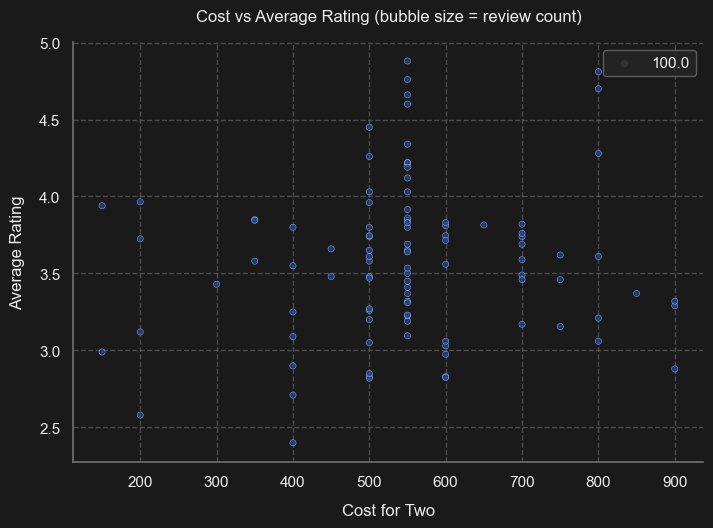

In [150]:
#### --16--
# Merge restaurant aggregates into metadata
feat_df = meta_df.merge(rest_agg, left_on='Name', right_on='Restaurant', how='left')

print(feat_df[['Name','Cost','Cuisine_Count','Collection_Count','Review_Count','Rating_Mean','Has_Pictures_Rate','Recency_Days']].head())

# --- Plot: Cost vs Rating with size by review count ---
plot_df = feat_df.dropna(subset=['Cost','Rating_Mean','Review_Count']).copy()
plot_df = plot_df.sort_values('Review_Count', ascending=False)

plt.figure(figsize=(9,6), facecolor='#1A1A1A')
ax = plt.gca()
ax.set_facecolor('#1A1A1A')

sns.scatterplot(
    data=plot_df,
    x='Cost', y='Rating_Mean',
    size='Review_Count', sizes=(20, 300),
    color='#1B47A7', alpha=0.75,
    edgecolor='#EDEDED', linewidth=0.3
)

ax.grid(True, color='#6D6D6D', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#6D6D6D')
ax.spines['bottom'].set_color('#6D6D6D')
ax.tick_params(colors='#EDEDED')
ax.set_title('Cost vs Average Rating (bubble size = review count)', color='#EDEDED', pad=15)
ax.set_xlabel('Cost for Two', color='#EDEDED', labelpad=10)
ax.set_ylabel('Average Rating', color='#EDEDED', labelpad=10)
leg = ax.legend(frameon=True)
if leg is not None:
    leg.get_frame().set_facecolor('#262626')
    leg.get_frame().set_edgecolor('#6D6D6D')
    for txt in leg.get_texts():
        txt.set_color('#EDEDED')

plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
plt.show()


                              Name       Value            Feature
0            The Fisherman's Wharf    7.000000   Collection_Count
1                  Beyond Flavours    6.000000   Collection_Count
2       Over The Moon Brew Company    5.000000   Collection_Count
3    The Lal Street - Bar Exchange    5.000000   Collection_Count
4                      Hyper Local    4.000000   Collection_Count
5                       Pot Pourri  900.000000               Cost
6                       Club Rogue  900.000000               Cost
7                      Owm Nom Nom  900.000000               Cost
8                     Dine O China  850.000000               Cost
9                  Beyond Flavours  800.000000               Cost
10                     Driven Cafe    0.600000  Has_Pictures_Rate
11       AB's - Absolute Barbecues    4.880000        Rating_Mean
12                          B-Dubs    4.810000        Rating_Mean
13  3B's - Buddies, Bar & Barbecue    4.760000        Rating_Mean
14        

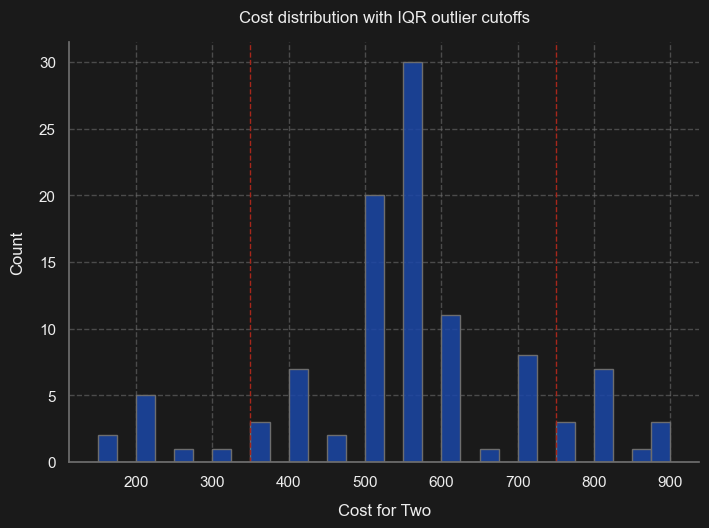

In [151]:
#### --17--

# Identify exceptional cases (outliers/anomalies) in engineered features and show examples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Helper: IQR outlier flags
def iqr_bounds(series_vals):
    series_clean = pd.to_numeric(series_vals, errors='coerce').dropna()
    if series_clean.shape[0] < 10:
        return np.nan, np.nan
    q1 = series_clean.quantile(0.25)
    q3 = series_clean.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Ensure feat_df exists
if 'feat_df' not in globals():
    feat_df = meta_df.merge(rest_agg, left_on='Name', right_on='Restaurant', how='left')

# Candidate numeric columns for exceptional cases
num_cols = ['Cost','Cuisine_Count','Collection_Count','Review_Count','Rating_Mean','Rating_Std','Has_Pictures_Rate','Recency_Days','Review_Len_Words_Mean']
num_cols = [c for c in num_cols if c in feat_df.columns]

outlier_rows_list = []
for col in num_cols:
    low_b, high_b = iqr_bounds(feat_df[col])
    if pd.isna(low_b) or pd.isna(high_b):
        continue
    mask_out = (feat_df[col] < low_b) | (feat_df[col] > high_b)
    tmp = feat_df.loc[mask_out, ['Name', col]].copy()
    tmp['Feature'] = col
    tmp = tmp.rename(columns={col: 'Value'})
    outlier_rows_list.append(tmp)

outliers_long = pd.concat(outlier_rows_list, ignore_index=True) if len(outlier_rows_list) > 0 else pd.DataFrame(columns=['Name','Value','Feature'])

# Missingness exceptional cases
missing_cols = ['Cost','Collections','Cuisines','Timings','Rating_Mean','Review_Count']
missing_cols = [c for c in missing_cols if c in feat_df.columns]
missing_any = feat_df[missing_cols].isna().any(axis=1)
missing_examples = feat_df.loc[missing_any, ['Name'] + missing_cols].head(10)

# Rating anomalies: mean rating very low/high with enough reviews
rating_anom = pd.DataFrame()
if 'Rating_Mean' in feat_df.columns and 'Review_Count' in feat_df.columns:
    rating_anom = feat_df.loc[(feat_df['Review_Count'] >= 30) & ((feat_df['Rating_Mean'] <= 2.5) | (feat_df['Rating_Mean'] >= 4.8)),
                              ['Name','Review_Count','Rating_Mean','Cost','Has_Pictures_Rate','Recency_Days']].sort_values(['Rating_Mean','Review_Count'], ascending=[True, False]).head(10)

# Recency anomalies: very stale restaurants
recency_anom = pd.DataFrame()
if 'Recency_Days' in feat_df.columns:
    recency_anom = feat_df.loc[feat_df['Recency_Days'].notna(), ['Name','Recency_Days','Review_Count','Rating_Mean','Cost']].sort_values('Recency_Days', ascending=False).head(10)

# Show top outliers per feature
top_outliers = pd.DataFrame()
if outliers_long.shape[0] > 0:
    top_outliers = (outliers_long.sort_values(['Feature','Value'], ascending=[True, False])
                    .groupby('Feature', dropna=False)
                    .head(5)
                    .reset_index(drop=True))

print(top_outliers.head(20))
print(missing_examples)
print(rating_anom)
print(recency_anom)

# One visualization: distribution of Cost with outlier thresholds
if 'Cost' in feat_df.columns:
    cost_low, cost_high = iqr_bounds(feat_df['Cost'])
    plt.figure(figsize=(9,6), facecolor='#1A1A1A')
    ax = plt.gca()
    ax.set_facecolor('#1A1A1A')
    sns.histplot(pd.to_numeric(feat_df['Cost'], errors='coerce').dropna(), bins=30, color='#1B47A7', edgecolor='#6D6D6D', alpha=0.85)
    if not pd.isna(cost_low):
        ax.axvline(cost_low, color='#A7271B', linestyle='--', linewidth=1)
    if not pd.isna(cost_high):
        ax.axvline(cost_high, color='#A7271B', linestyle='--', linewidth=1)
    ax.grid(True, color='#6D6D6D', linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#6D6D6D')
    ax.spines['bottom'].set_color('#6D6D6D')
    ax.tick_params(colors='#EDEDED')
    ax.set_title('Cost distribution with IQR outlier cutoffs', color='#EDEDED', pad=15)
    ax.set_xlabel('Cost for Two', color='#EDEDED', labelpad=10)
    ax.set_ylabel('Count', color='#EDEDED', labelpad=10)
    plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
    plt.show()
    

In [153]:
#### --18--
# Install required NLP libraries
%pip install textblob vaderSentiment tqdm


Note: you may need to restart the kernel to use updated packages.


In [154]:
#### --19--
# Check what dataframes/variables are available in memory
import pandas as pd
import numpy as np

# List all dataframes in memory
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)
        

_ (3, 18)
__ (3, 18)
___ (3, 15)
meta_df (105, 20)
reviews_df (10000, 20)
meta_missing_compare (18, 2)
reviews_missing_compare (14, 2)
rest_agg (100, 9)
last_dates (100, 2)
feat_df (105, 29)
plot_df (100, 29)
tmp (0, 3)
outliers_long (60, 3)
missing_examples (5, 7)
rating_anom (3, 6)
recency_anom (10, 5)
top_outliers (24, 3)
monthly_counts (997, 3)
avg_velocity (100, 2)
reviewer_agg_df (7447, 5)
meta_use_df (105, 12)
rest_features_df (100, 21)
extracted_times (105, 2)
failed (10, 3)
bucket_cols_df (105, 6)
failed2 (20, 3)
bucket_cols_df2 (105, 6)
ex_df (4, 10)
failed3 (25, 3)
daypart_df (105, 8)
examples_df (12, 10)
dayparts_df (105, 8)
sample_view (12, 42)
updated_dayparts_df (105, 8)
row0_view (1, 10)
parsed_dayparts_df (105, 8)
new_daypart_df (105, 8)
parts_df (105, 8)
parsed_df (105, 8)
meta_parsed_df (105, 10)
timing_df (105, 8)
timing_features (105, 8)
_93 (3, 66)
_103 (3, 15)
closed_unique_df (105, 1)
closed_counts_df (1, 2)
non_empty_closed_df (0, 5)
_122 (3, 18)
_123 (3, 18)
_

In [155]:
#### --20--
# Quick peek at current columns in reviews_df and fe_df
print("reviews_df columns:", list(reviews_df.columns))
print("\feat_df columns:", list(feat_df.columns))
print("\reviews_df head:")
print(reviews_df[['Review', 'Rating', 'Time_Parsed']].head(3))


reviews_df columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Rating_Num', 'Time_Parsed', 'Reviewer_Review_Count', 'Reviewer_Follower_Count', 'Has_Pictures', 'Reviewer_Review_Count_Missing', 'Reviewer_Follower_Count_Missing', 'Review_Len_Chars', 'Review_Len_Words', 'Review_Year', 'Review_Month', 'Review_DayOfWeek', 'Review_Hour']
eat_df columns: ['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings', 'Timings_Clean', 'morning_open_time', 'morning_close_time', 'afternoon_open_time', 'afternoon_close_time', 'evening_open_time', 'evening_close_time', 'night_open_time', 'night_close_time', 'Open_Days', 'Closed_Days', 'Is_Open_All_Week', 'Cuisine_Count', 'Collection_Count', 'Restaurant', 'Review_Count', 'Rating_Mean', 'Rating_Median', 'Rating_Std', 'Review_Len_Words_Mean', 'Has_Pictures_Rate', 'Last_Review_Date', 'Recency_Days']
eviews_df head:
                                              Review Rating   
0  The ambience was good, food was qui

In [156]:
#### --21--
## Text / NLP Features

# Stage 1: Text/NLP features using VADER + TextBlob
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm
import re

tqdm.pandas()
analyzer = SentimentIntensityAnalyzer()

# VADER sentiment scores
print("Computing VADER sentiment...")
vader_scores = reviews_df['Review'].fillna('').progress_apply(
    lambda x: analyzer.polarity_scores(x)
)
reviews_df['Vader_Compound'] = vader_scores.apply(lambda x: x['compound'])
reviews_df['Vader_Pos'] = vader_scores.apply(lambda x: x['pos'])
reviews_df['Vader_Neg'] = vader_scores.apply(lambda x: x['neg'])

# TextBlob polarity & subjectivity
print("Computing TextBlob sentiment...")
tb_scores = reviews_df['Review'].fillna('').progress_apply(lambda x: TextBlob(x).sentiment)
reviews_df['TB_Polarity'] = tb_scores.apply(lambda x: x.polarity)
reviews_df['TB_Subjectivity'] = tb_scores.apply(lambda x: x.subjectivity)

# Sentiment category from VADER compound
reviews_df['Sentiment_Category'] = pd.cut(
    reviews_df['Vader_Compound'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)

print("Done!")
print(reviews_df[['Vader_Compound', 'TB_Polarity', 'TB_Subjectivity', 'Sentiment_Category']].head())


Computing VADER sentiment...


100%|███████████████████████████████████| 10000/10000 [00:02<00:00, 3770.61it/s]


Computing TextBlob sentiment...


100%|███████████████████████████████████| 10000/10000 [00:02<00:00, 3489.95it/s]

Done!
   Vader_Compound  TB_Polarity  TB_Subjectivity Sentiment_Category
0          0.9676     0.660000         0.720000           Positive
1          0.9360     0.606667         0.613333           Positive
2          0.9186     0.540000         0.740000           Positive
3          0.8591     0.500000         0.783333           Positive
4          0.9245     0.577500         0.570000           Positive


In [157]:
#### --22--
# Adding the  NLP features: keyword flags, punctuation counts, caps ratio, review quality score

# Keyword flags - binary indicators for common review topics
keywords = {
    'kw_ambience': r'\bambien(?:ce|t)\b',
    'kw_service': r'\bservice\b',
    'kw_value': r'\bvalue\b|\bworth\b|\baffordable\b|\bpricey\b|\bexpensive\b|\bcheap\b',
    'kw_spicy': r'\bspicy\b|\bspice\b',
    'kw_rude': r'\brude\b|\bunfriendly\b|\barrogant\b|\bdisrespect\b',
    'kw_taste': r'\btaste\b|\btasty\b|\bdelicious\b|\byummy\b|\bflavou?r\b',
    'kw_wait': r'\bwait\b|\bwaiting\b|\bslow\b|\bdelay\b',
    'kw_recommend': r'\brecommend\b|\bmust.?try\b|\bworth.?visit\b',
}

for col, pattern in keywords.items():
    reviews_df[col] = reviews_df['Review'].fillna('').str.contains(
        pattern, case=False, regex=True
    ).astype(int)


In [158]:
#### --23--
# Exclamation/Question counts, Caps Ratio, and Review Quality Score

# Punctuation counts
reviews_df['Exclamation_Count'] = reviews_df['Review'].fillna('').str.count(r'!')
reviews_df['Question_Count'] = reviews_df['Review'].fillna('').str.count(r'\?')

# Caps ratio: ratio of uppercase letters to total letters
def caps_ratio(text):
    letters = [c for c in str(text) if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

reviews_df['Caps_Ratio'] = reviews_df['Review'].fillna('').apply(caps_ratio)

# Review Quality Score: composite of:
# - normalized review length (words, capped at 200)
# - absolute sentiment strength (|vader compound|)
# - punctuation richness (unique punctuation chars / review length)
def review_quality(row):
    length_score = min(row['Review_Len_Words'], 200) / 200  # 0-1
    sentiment_strength = abs(row['Vader_Compound'])          # 0-1
    text = str(row['Review']) if pd.notna(row['Review']) else ''
    punct_chars = set(c for c in text if c in '!?.,;:-()"\'' )
    punct_score = min(len(punct_chars) / 10, 1.0)            # 0-1, capped
    return round((length_score + sentiment_strength + punct_score) / 3, 4)

from tqdm import tqdm
tqdm.pandas()
reviews_df['Review_Quality_Score'] = reviews_df.progress_apply(review_quality, axis=1)

print("All features added!")
print(reviews_df[['Exclamation_Count', 'Question_Count', 'Caps_Ratio', 'Review_Quality_Score']].head())


100%|██████████████████████████████████| 10000/10000 [00:00<00:00, 56365.96it/s]

All features added!
   Exclamation_Count  Question_Count  Caps_Ratio  Review_Quality_Score
0                  0               0    0.040000                0.4575
1                  0               0    0.053097                0.4237
2                  0               0    0.062069                0.4579
3                  0               0    0.042735                0.3997
4                  0               0    0.062992                0.3865


In [160]:
#### --24--
# Temporal features - basic flags from existing time columns
reviews_df['Is_Weekend'] = (reviews_df['Review_DayOfWeek'] >= 5).astype(int)

reviews_df['Is_Lunch'] = reviews_df['Review_Hour'].apply(
    lambda h: 1 if 11 <= h <= 15 else 0
)
reviews_df['Is_Dinner'] = reviews_df['Review_Hour'].apply(
    lambda h: 1 if 18 <= h <= 22 else 0
)

# Season based on month (Indian seasons)
def get_season(month):
    if month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9, 10]:
        return 'Monsoon'
    else:
        return 'Winter'

reviews_df['Season'] = reviews_df['Review_Month'].apply(get_season)

print("Basic temporal flags done!")
print(reviews_df[['Review_Month', 'Review_DayOfWeek', 'Review_Hour', 'Is_Weekend', 'Is_Lunch', 'Is_Dinner', 'Season']].head())


Basic temporal flags done!
   Review_Month  Review_DayOfWeek  Review_Hour  Is_Weekend  Is_Lunch   
0           5.0               5.0         15.0           1         1  \
1           5.0               5.0         14.0           1         1   
2           5.0               4.0         22.0           0         0   
3           5.0               4.0         22.0           0         0   
4           5.0               4.0         21.0           0         0   

   Is_Dinner  Season  
0          0  Summer  
1          0  Summer  
2          1  Summer  
3          1  Summer  
4          1  Summer  


In [162]:
#### --25--
# Use 'Restaurant' as the groupby key and 'Time_Parsed' for date calculations
first_review_date = reviews_df.groupby('Restaurant')['Time_Parsed'].transform('min')
reviews_df['Days_Since_First_Review'] = (reviews_df['Time_Parsed'] - first_review_date).dt.days

print("Days_Since_First_Review done!")
print(reviews_df[['Restaurant', 'Time_Parsed', 'Days_Since_First_Review']].head())


Days_Since_First_Review done!
        Restaurant         Time_Parsed  Days_Since_First_Review
0  Beyond Flavours 2019-05-25 15:54:00                     22.0
1  Beyond Flavours 2019-05-25 14:20:00                     22.0
2  Beyond Flavours 2019-05-24 22:54:00                     21.0
3  Beyond Flavours 2019-05-24 22:11:00                     21.0
4  Beyond Flavours 2019-05-24 21:37:00                     21.0


In [168]:
#### --26--
# Review_Velocity - average number of reviews per month per restaurant (e.g. Beyond Flavours gets ~100/month — very active!)
# Count reviews per restaurant per year-month, then compute rolling/average velocity

# Step 1: create a year-month period column

reviews_df['YearMonth'] = reviews_df['Time_Parsed'].dt.to_period('M')

# Re-compute Review_Velocity cleanly from scratch
monthly_counts = reviews_df.groupby(['Restaurant', 'YearMonth']).size().reset_index(name='Monthly_Review_Count')
avg_velocity = monthly_counts.groupby('Restaurant')['Monthly_Review_Count'].mean().reset_index()
avg_velocity.columns = ['Restaurant', 'Review_Velocity']

# Map it directly instead of merge to avoid duplicate column issues
velocity_map = avg_velocity.set_index('Restaurant')['Review_Velocity']
reviews_df['Review_Velocity'] = reviews_df['Restaurant'].map(velocity_map)

print("Review_Velocity added! Unique NaN count: " + str(reviews_df['Review_Velocity'].isna().sum()))
print(reviews_df[['Restaurant', 'YearMonth', 'Days_Since_First_Review', 'Review_Velocity']].head(100))


Review_Velocity added! Unique NaN count: 0
         Restaurant YearMonth  Days_Since_First_Review  Review_Velocity
0   Beyond Flavours   2019-05                     22.0            100.0
1   Beyond Flavours   2019-05                     22.0            100.0
2   Beyond Flavours   2019-05                     21.0            100.0
3   Beyond Flavours   2019-05                     21.0            100.0
4   Beyond Flavours   2019-05                     21.0            100.0
..              ...       ...                      ...              ...
95  Beyond Flavours   2019-05                      1.0            100.0
96  Beyond Flavours   2019-05                      0.0            100.0
97  Beyond Flavours   2019-05                      0.0            100.0
98  Beyond Flavours   2019-05                      0.0            100.0
99  Beyond Flavours   2019-05                      0.0            100.0

[100 rows x 4 columns]


In [24]:

print(reviews_df['Rating_Num'].isna().sum())
print(reviews_df[['Rating', 'Rating_Num']].head(10))


0
  Rating  Rating_Num
0      5         5.0
1      5         5.0
2      5         5.0
3      5         5.0
4      5         5.0
5      5         5.0
6      5         5.0
7      4         4.0
8      5         5.0
9      5         5.0


In [169]:
#### --27--
# Compute reviewer-level features using numeric ratings and map back to reviews_df
import numpy as np
import pandas as pd

# Global average rating for bias calculation (numeric)
global_avg_rating_num = reviews_df['Rating_Num'].mean()

reviewer_agg_df = (
    reviews_df.groupby('Reviewer', dropna=False)
    .agg(
        Reviewer_Avg_Rating=('Rating_Num', 'mean'),
        Reviewer_Review_Count_calc=('Rating_Num', 'size')
    )
    .reset_index()
)

reviewer_agg_df['Reviewer_Rating_Bias'] = reviewer_agg_df['Reviewer_Avg_Rating'] - global_avg_rating_num

# Power reviewer threshold - top 10 percent by review count
power_threshold_cnt = reviewer_agg_df['Reviewer_Review_Count_calc'].quantile(0.90)
reviewer_agg_df['Is_Power_Reviewer'] = (reviewer_agg_df['Reviewer_Review_Count_calc'] >= power_threshold_cnt).astype(int)

# Map back (merge) while keeping existing columns
reviews_df = reviews_df.merge(
    reviewer_agg_df[['Reviewer', 'Reviewer_Avg_Rating', 'Reviewer_Rating_Bias', 'Is_Power_Reviewer']],
    on='Reviewer',
    how='left',
    validate='m:1'
)

print(round(global_avg_rating_num, 4))
print(power_threshold_cnt)
print(reviews_df[['Reviewer', 'Rating', 'Rating_Num', 'Reviewer_Avg_Rating', 'Reviewer_Rating_Bias', 'Is_Power_Reviewer']].head(10))


3.587
2.0
               Reviewer Rating  Rating_Num  Reviewer_Avg_Rating   
0     Rusha Chakraborty      5         5.0             5.000000  \
1  Anusha Tirumalaneedi      5         5.0             5.000000   
2       Ashok Shekhawat      5         5.0             5.000000   
3        Swapnil Sarkar      5         5.0             5.000000   
4                Dileep      5         5.0             4.333333   
5         Nagabhavani K      5         5.0             5.000000   
6       Jamuna Bhuwalka      5         5.0             5.000000   
7             Sandhya S      4         4.0             4.000000   
8          Akash Thorat      5         5.0             5.000000   
9        Smarak Patnaik      5         5.0             5.000000   

   Reviewer_Rating_Bias  Is_Power_Reviewer  
0              1.413000                  0  
1              1.413000                  0  
2              1.413000                  0  
3              1.413000                  0  
4              0.746333    

In [171]:
#### --28--
# Feature engineering at restaurant level using existing meta_df and reviews_df
import pandas as pd
import numpy as np


# Basic restaurant-level aggregates from reviews
rest_agg = (
    reviews_df.groupby('Restaurant', dropna=False)
    .agg(
        Review_Count=('Rating_Num', 'size'),
        Rating_Mean=('Rating_Num', 'mean'),
        Rating_Median=('Rating_Num', 'median'),
        Rating_Std=('Rating_Num', 'std'),
        Has_Pictures_Rate=('Has_Pictures', 'mean'),
        First_Review_Date=('Time_Parsed', 'min'),
        Last_Review_Date=('Time_Parsed', 'max')
    )
    .reset_index()
)

# Rating consistency as inverse of std (guard against 0 / NaN)
rest_agg['Rating_Consistency'] = 1.0 / (rest_agg['Rating_Std'].fillna(0) + 1e-6)

# Recency (staleness)
max_date_val = reviews_df['Time_Parsed'].max()
rest_agg['Recency_Days'] = (max_date_val - rest_agg['Last_Review_Date']).dt.days
stale_threshold_days = float(rest_agg['Recency_Days'].quantile(0.75))
rest_agg['Is_Stale'] = (rest_agg['Recency_Days'] > stale_threshold_days).astype(int)

# Review velocity as reviews per month over active window
active_days = (rest_agg['Last_Review_Date'] - rest_agg['First_Review_Date']).dt.days
active_months = (active_days.clip(lower=1) / 30.4375)
rest_agg['Review_Velocity'] = rest_agg['Review_Count'] / active_months

# Join meta features (cost, cuisines, collections)
meta_use_df = meta_df.copy()
meta_use_df['Is_Multi_Cuisine'] = (meta_use_df['Cuisine_Count'] > 1).astype(int)

premium_cutoff = float(meta_use_df['Cost'].quantile(0.75))
meta_use_df['Is_Premium'] = (meta_use_df['Cost'] > premium_cutoff).astype(int)

# Cost per cuisine
meta_use_df['Cost_Per_Cuisine'] = meta_use_df['Cost'] / meta_use_df['Cuisine_Count'].replace({0: np.nan})

# Collection prestige score (simple weighted mapping)
collection_weight_map = {
    'Top-Rated': 3.0,
    'Top Rated': 3.0,
    'Best': 2.5,
    'Legendary': 2.5,
    'Popular': 2.0,
    'Trending': 2.0,
    'New': 1.5,
    'Hygiene': 1.5,
    'Favorites': 1.5,
    'Budget': 1.0,
    'Pocket Friendly': 1.0,
    'Luxury': 2.0
}

def compute_prestige_score(collections_val):
    if pd.isna(collections_val):
        return 0.0
    coll_parts = [c.strip() for c in str(collections_val).split(',') if str(c).strip() != '']
    if len(coll_parts) == 0:
        return 0.0
    score_val = 0.0
    for coll_item in coll_parts:
        weight_val = 1.0
        for key_val in collection_weight_map:
            if key_val.lower() in coll_item.lower():
                weight_val = max(weight_val, collection_weight_map[key_val])
        score_val = score_val + weight_val
    return float(score_val)

meta_use_df['Collection_Prestige_Score'] = meta_use_df['Collections'].apply(compute_prestige_score)

# Merge restaurant aggregates with meta (best-effort join on name)
rest_features_df = rest_agg.merge(
    meta_use_df[[
        'Name', 'Cost', 'Cuisine_Count', 'Collection_Count', 'Is_Multi_Cuisine', 'Is_Premium',
        'Cost_Per_Cuisine', 'Collection_Prestige_Score', 'Cuisines', 'Collections'
    ]],
    left_on='Restaurant',
    right_on='Name',
    how='left'
)

# Tidy up
rest_features_df = rest_features_df.drop(columns=['Name'])

print(rest_features_df.head())
print(rest_features_df[['Review_Count','Rating_Mean','Rating_Median','Rating_Std','Rating_Consistency','Recency_Days','Is_Stale','Review_Velocity','Has_Pictures_Rate','Is_Multi_Cuisine','Is_Premium','Cost_Per_Cuisine','Collection_Prestige_Score']].describe(include='all'))
print(stale_threshold_days)
print(premium_cutoff)


                       Restaurant  Review_Count  Rating_Mean  Rating_Median   
0               10 Downing Street           100         3.80            4.0  \
1                        13 Dhaba           100         3.48            4.0   
2  3B's - Buddies, Bar & Barbecue           100         4.76            5.0   
3       AB's - Absolute Barbecues           100         4.88            5.0   
4               Absolute Sizzlers           100         3.62            4.0   

   Rating_Std  Has_Pictures_Rate   First_Review_Date    Last_Review_Date   
0    1.091751               0.24 2018-10-18 20:58:00 2019-05-23 21:04:00  \
1    1.566570               0.19 2018-08-04 23:45:00 2019-05-25 15:05:00   
2    0.830237               0.07 2019-04-15 20:44:00 2019-05-23 23:39:00   
3    0.498077               0.07 2019-05-07 22:40:00 2019-05-25 16:20:00   
4    1.581330               0.11 2019-02-23 23:55:00 2019-05-21 21:45:00   

   Rating_Consistency  Recency_Days  ...  Review_Velocity   Cost   


In [187]:
#### --29--
# Implement interaction/ratio features on reviews_df, then show a quick sanity-check preview
import numpy as np
import pandas as pd

# Rating vs reviewer's average
# Rating_Num - Reviewer_Avg_Rating- This flags whether the reviewer rated this place unusually high or low relative to their own baseline.
reviews_df['Rating_vs_Reviewer_Avg'] = reviews_df['Rating_Num'] - reviews_df['Reviewer_Avg_Rating']

# Review_Length_x_Sentiment - Review_Length * sentiment_score
# Assumption: sentiment is in Sentiment_Score if present; else use Rating-centered proxy (rating - global avg)
# Ensure Review_Length exists
if 'Review_Length' not in reviews_df.columns:
    reviews_df['Review_Length'] = reviews_df['Review'].fillna('').astype(str).str.split().str.len()

# Detect sentiment column
sent_col = None
for cand in ['Vader_Compound', 'TB_Polarity', 'Sentiment_Score']:
    if cand in reviews_df.columns:
        sent_col = cand
        break

if sent_col is None:
    reviews_df['Sentiment_Score'] = 0
    sent_col = 'Sentiment_Score'

# Create feature
reviews_df['Review_Length_x_Sentiment'] = (
    reviews_df['Review_Length'] * pd.to_numeric(reviews_df[sent_col], errors='coerce')
)
reviews_df['Review_Length_x_Sentiment'] = reviews_df['Review_Length'] * pd.to_numeric(reviews_df[sent_col], errors='coerce')

# Cost_x_Rating (join restaurant cost from meta_df; guard if already present)  = Cost * Rating_Num (pure interaction)
if 'Cost' not in reviews_df.columns:
    reviews_df['Cost'] = np.nan

reviews_df['Cost'] = pd.to_numeric(reviews_df['Cost'], errors='coerce')

reviews_df['Cost_x_Rating'] = reviews_df['Cost'] * reviews_df['Rating_Num']

reviews_df['Rating_per_Cost_100'] = (
    reviews_df['Rating_Num'] / reviews_df['Cost'].replace({0: np.nan})
) * 100

# Value-for-money proxy: rating per cost unit (scaled) and cost*rating (interaction)
reviews_df['Cost_x_Rating'] = reviews_df['Cost'] * reviews_df['Rating_Num']
# = (Rating_Num / Cost) * 100 (ratio, typically a more direct value-for-money proxy)
reviews_df['Rating_per_Cost_100'] = (reviews_df['Rating_Num'] / reviews_df['Cost'].replace({0: np.nan})) * 100

# Followers_x_Rating
# Assumption: followers column might be Followers or Follower_Count; if absent, create as NaN
followers_col = None
for cand_f in ['Followers', 'Follower_Count', 'Followers_Count', 'Reviewer_Followers']:
    if cand_f in reviews_df.columns:
        followers_col = cand_f
        break

if followers_col is None:
    reviews_df['Followers'] = np.nan
    followers_col = 'Followers'

reviews_df[followers_col] = pd.to_numeric(reviews_df[followers_col], errors='coerce')
reviews_df['Followers_x_Rating'] = reviews_df[followers_col] * reviews_df['Rating_Num']

# Quick preview
preview_cols = ['Restaurant', 'Reviewer', 'Rating_Num', 'Reviewer_Avg_Rating', 'Rating_vs_Reviewer_Avg',
                'Review_Length', sent_col, 'Review_Length_x_Sentiment', 'Cost', 'Cost_x_Rating',
                'Rating_per_Cost_100', followers_col, 'Followers_x_Rating']
preview_cols = [c for c in preview_cols if c in reviews_df.columns]

print(reviews_df[preview_cols].head(10))
print(reviews_df[['Rating_vs_Reviewer_Avg', 'Review_Length_x_Sentiment', 'Cost_x_Rating', 'Followers_x_Rating', 'Rating_per_Cost_100']].describe(include='all'))


        Restaurant              Reviewer  Rating_Num  Reviewer_Avg_Rating   
0  Beyond Flavours     Rusha Chakraborty         5.0             5.000000  \
1  Beyond Flavours  Anusha Tirumalaneedi         5.0             5.000000   
2  Beyond Flavours       Ashok Shekhawat         5.0             5.000000   
3  Beyond Flavours        Swapnil Sarkar         5.0             5.000000   
4  Beyond Flavours                Dileep         5.0             4.333333   
5  Beyond Flavours         Nagabhavani K         5.0             5.000000   
6  Beyond Flavours       Jamuna Bhuwalka         5.0             5.000000   
7  Beyond Flavours             Sandhya S         4.0             4.000000   
8  Beyond Flavours          Akash Thorat         5.0             5.000000   
9  Beyond Flavours        Smarak Patnaik         5.0             5.000000   

   Rating_vs_Reviewer_Avg  Review_Length  Vader_Compound   
0                0.000000             41          0.9676  \
1                0.000000       

## Problem Statement:

### Problem statement: Personalized restaurant ranking and recommendation pipeline

#### Background
We have a dataset of restaurant reviews where each record represents a **user–restaurant interaction** (a reviewer left a rating and a text review). We’ve already engineered rich signals from this data, including **sentiment/NLP features**, **temporal behavior**, and **restaurant-level quality and popularity aggregates**. The goal now is to turn these signals into a system that can recommend restaurants *per user*, not just “top restaurants overall”.

#### Objective
Build a **user-specific ranking pipeline** that, given a user `u` and a set of candidate restaurants `R`, outputs a **ranked list of restaurants** that the user is most likely to enjoy.

In other words, learn a function:

$$Score(u, r) \rightarrow \mathbb{R}$$

such that sorting restaurants by `Score(u, r)` yields the best personalized recommendations for that user.


In [188]:
#### --30--
# Load required libraries and check that expected dataframes exist in memory
import pandas as pd
import numpy as np

needed_names = ['reviews_df', 'meta_df']
for nm in needed_names:
    print(nm in globals())

if 'reviews_df' in globals():
    print(reviews_df.shape)
    print(reviews_df.head())

if 'meta_df' in globals():
    print(meta_df.shape)
    print(meta_df.head())
    
# Install lightgbm if needed (fast check) and import
import importlib

lightgbm_spec = importlib.util.find_spec('lightgbm')
print(lightgbm_spec is not None)

if lightgbm_spec is None:
    %pip install lightgbm

import lightgbm as lgb
print(lgb.__version__)

True
True
(10000, 56)
        Restaurant              Reviewer   
0  Beyond Flavours     Rusha Chakraborty  \
1  Beyond Flavours  Anusha Tirumalaneedi   
2  Beyond Flavours       Ashok Shekhawat   
3  Beyond Flavours        Swapnil Sarkar   
4  Beyond Flavours                Dileep   

                                              Review Rating   
0  The ambience was good, food was quite good . h...      5  \
1  Ambience is too good for a pleasant evening. S...      5   
2  A must try.. great food great ambience. Thnx f...      5   
3  Soumen das and Arun was a great guy. Only beca...      5   
4  Food is good.we ordered Kodi drumsticks and ba...      5   

                  Metadata             Time  Pictures  Rating_Num   
0   1 Review , 2 Followers  5/25/2019 15:54         0         5.0  \
1  3 Reviews , 2 Followers  5/25/2019 14:20         0         5.0   
2  2 Reviews , 3 Followers  5/24/2019 22:54         0         5.0   
3    1 Review , 1 Follower  5/24/2019 22:11         0     

In [180]:
pip install ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 10.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [189]:
#### --31--
# Fix cuisine multihot creation (use re.escape instead of pd.regex.escape) and rebuild feat_df_rank
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

df0 = reviews_df.copy()

rating_vals = pd.to_numeric(df0['Rating_Num'], errors='coerce')
rel_map = {5: 3, 4: 2, 3: 1, 2: 0, 1: 0}
df0['relevance'] = rating_vals.round().clip(1, 5).astype('Int64').map(rel_map).astype('float')

meta_tmp = meta_df.copy()
meta_tmp['Cost_Num'] = pd.to_numeric(meta_tmp['Cost'].astype(str).str.replace(',', ''), errors='coerce')

rest_agg = df0.groupby('Restaurant', as_index=False).agg(
    Rest_Rating_Mean=('Rating_Num', 'mean'),
    Rest_Rating_Std=('Rating_Num', 'std'),
    Rest_Review_Count=('Rating_Num', 'size'),
    Rest_Vader_Mean=('Vader_Compound', 'mean'),
    Rest_ReviewLen_Mean=('Review_Len_Words', 'mean')
)
rest_agg['Rest_Rating_Std'] = rest_agg['Rest_Rating_Std'].fillna(0.0)

user_agg = df0.groupby('Reviewer', as_index=False).agg(
    User_Rating_Mean=('Rating_Num', 'mean'),
    User_Rating_Std=('Rating_Num', 'std'),
    User_Review_Count=('Rating_Num', 'size'),
    User_Vader_Mean=('Vader_Compound', 'mean'),
    User_ReviewLen_Mean=('Review_Len_Words', 'mean')
)
user_agg['User_Rating_Std'] = user_agg['User_Rating_Std'].fillna(0.0)

meta_tmp['Cuisines_Clean'] = meta_tmp['Cuisines'].fillna('').astype(str).str.lower()
all_cuis_tokens = meta_tmp['Cuisines_Clean'].str.split(',').explode().str.strip()
top_k = 25
cuisine_top = all_cuis_tokens.value_counts().head(top_k).index.tolist()

for c in cuisine_top:
    col_nm = 'cuisine_' + c.replace(' ', '_').replace('&', 'and').replace('-', '_')
    patt = r'(^|,\s*)' + re.escape(c) + r'(,|$)'
    meta_tmp[col_nm] = meta_tmp['Cuisines_Clean'].str.contains(patt, regex=True).astype(int)

cuisine_cols = [c for c in meta_tmp.columns if c.startswith('cuisine_')]

rest_feat = meta_tmp[['Name', 'Cost_Num', 'Cuisine_Count', 'Collection_Count'] + cuisine_cols].rename(columns={'Name': 'Restaurant'})
rest_feat = rest_feat.merge(rest_agg, on='Restaurant', how='left')
rest_feat['Is_Premium'] = (rest_feat['Cost_Num'] >= rest_feat['Cost_Num'].median(skipna=True)).astype(int)
rest_feat['Collections_Prestige'] = rest_feat['Collection_Count'].fillna(0)

u_r = df0[['Reviewer', 'Restaurant']].drop_duplicates()
u_r = u_r.merge(rest_feat[['Restaurant'] + cuisine_cols], on='Restaurant', how='left')
user_cuisine_pref = u_r.groupby('Reviewer', as_index=False)[cuisine_cols].mean()
user_cuisine_pref = user_cuisine_pref.rename(columns={c: 'userpref_' + c for c in cuisine_cols})

user_cost_pref = df0[['Reviewer', 'Restaurant']].drop_duplicates().merge(rest_feat[['Restaurant', 'Cost_Num']], on='Restaurant', how='left')
user_cost_pref = user_cost_pref.groupby('Reviewer', as_index=False).agg(User_Cost_Median=('Cost_Num', 'median'))

pos_pairs = df0[['Reviewer', 'Restaurant']].drop_duplicates(subset=['Reviewer', 'Restaurant'], keep='last')
pos_pairs = pos_pairs.merge(df0[['Reviewer', 'Restaurant', 'relevance', 'Rating_Num']], on=['Reviewer', 'Restaurant'], how='left')
pos_pairs = pos_pairs.drop_duplicates(subset=['Reviewer', 'Restaurant'], keep='last')

all_restaurants = rest_feat['Restaurant'].dropna().unique().tolist()
neg_per_pos = 3
rng = np.random.default_rng(7)
user_to_seen = pos_pairs.groupby('Reviewer')['Restaurant'].apply(set).to_dict()

rows = []
for idx in tqdm(range(len(pos_pairs)), desc='building pairs'):
    u = pos_pairs.iloc[idx]['Reviewer']
    r_pos = pos_pairs.iloc[idx]['Restaurant']
    rel = pos_pairs.iloc[idx]['relevance']
    rows.append([u, r_pos, rel, 1])

    seen = user_to_seen.get(u, set())
    if len(all_restaurants) <= len(seen) + 1:
        continue

    negs = []
    while len(negs) < neg_per_pos:
        r_cand = all_restaurants[int(rng.integers(0, len(all_restaurants)))]
        if (r_cand not in seen) and (r_cand != r_pos):
            negs.append(r_cand)
    for r_neg in negs:
        rows.append([u, r_neg, 0.0, 0])

pairs_df = pd.DataFrame(rows, columns=['Reviewer', 'Restaurant', 'label', 'is_pos'])

feat_df_rank = pairs_df.merge(user_agg, on='Reviewer', how='left')
feat_df_rank = feat_df_rank.merge(user_cuisine_pref, on='Reviewer', how='left')
feat_df_rank = feat_df_rank.merge(user_cost_pref, on='Reviewer', how='left')
feat_df_rank = feat_df_rank.merge(rest_feat, on='Restaurant', how='left')

feat_df_rank['Cost_Gap'] = (feat_df_rank['Cost_Num'] - feat_df_rank['User_Cost_Median']).abs()

userpref_cols = ['userpref_' + c for c in cuisine_cols]
feat_df_rank['Cuisine_Overlap'] = 0.0
if len(cuisine_cols) > 0:
    rest_mat = feat_df_rank[cuisine_cols].fillna(0).to_numpy(dtype=float)
    user_mat = feat_df_rank[userpref_cols].fillna(0).to_numpy(dtype=float)
    feat_df_rank['Cuisine_Overlap'] = (rest_mat * user_mat).sum(axis=1)

feat_df_rank['Expected_Rating_vs_User_Mean'] = feat_df_rank['Rest_Rating_Mean'] - feat_df_rank['User_Rating_Mean']

print(feat_df_rank.shape)
print(feat_df_rank[['Reviewer','Restaurant','label','is_pos','Cost_Num','User_Cost_Median','Cost_Gap','Cuisine_Overlap']].head())


/var/folders/_x/tbwxp4nj3t339_cq3yylphrh0000gn/T/ipykernel_24115/3224554192.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  meta_tmp[col_nm] = meta_tmp['Cuisines_Clean'].str.contains(patt, regex=True).astype(int)
/var/folders/_x/tbwxp4nj3t339_cq3yylphrh0000gn/T/ipykernel_24115/3224554192.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  meta_tmp[col_nm] = meta_tmp['Cuisines_Clean'].str.contains(patt, regex=True).astype(int)
/var/folders/_x/tbwxp4nj3t339_cq3yylphrh0000gn/T/ipykernel_24115/3224554192.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  meta_tmp[col_nm] = meta_tmp['Cuisines_Clean'].str.contains(patt, regex=True).astype(int)
/var/folders/_x/tbwxp4nj3t339_cq3yylphrh0000gn/T/ipykernel_24115/3224554192.py:

(39380, 73)
               Reviewer                               Restaurant  label   
0     Rusha Chakraborty                          Beyond Flavours    3.0  \
1     Rusha Chakraborty                         Chinese Pavilion    0.0   
2     Rusha Chakraborty  Komatose - Holiday Inn Express & Suites    0.0   
3     Rusha Chakraborty                        Eat India Company    0.0   
4  Anusha Tirumalaneedi                          Beyond Flavours    3.0   

   is_pos  Cost_Num  User_Cost_Median  Cost_Gap  Cuisine_Overlap  
0       1     800.0             800.0       0.0              6.0  
1       0     500.0             800.0     300.0              1.0  
2       0     550.0             800.0     250.0              2.0  
3       0     500.0             800.0     300.0              1.0  
4       1     800.0             800.0       0.0              6.0  


In [190]:
#### --32--
# Train a LightGBM ranker (LambdaRank) and evaluate with NDCG@k.
import numpy as np
import pandas as pd

# Prepare groups (queries) by Reviewer
rank_df = feat_df_rank.copy()

# Remove identifiers from feature matrix
non_feature_cols = ['Reviewer', 'Restaurant', 'label', 'is_pos']
feature_cols = [c for c in rank_df.columns if c not in non_feature_cols]

# Basic NA handling
for c in feature_cols:
    if rank_df[c].dtype.kind in ['i', 'u', 'f']:
        rank_df[c] = rank_df[c].astype(float).fillna(0.0)
    else:
        rank_df[c] = rank_df[c].fillna('')

# Sort by Reviewer to make group array
rank_df = rank_df.sort_values(['Reviewer']).reset_index(drop=True)

# Train-test split by users (avoid leakage)
rng = np.random.default_rng(42)
unique_users = rank_df['Reviewer'].unique()
mask = rng.random(len(unique_users)) < 0.8
train_users = set(unique_users[mask])
test_users = set(unique_users[~mask])

train_df_rank = rank_df[rank_df['Reviewer'].isin(train_users)].copy()
test_df_rank = rank_df[rank_df['Reviewer'].isin(test_users)].copy()

# Re-sort within each set
train_df_rank = train_df_rank.sort_values(['Reviewer']).reset_index(drop=True)
test_df_rank = test_df_rank.sort_values(['Reviewer']).reset_index(drop=True)

# Group sizes
def group_sizes(df_in):
    grp = df_in.groupby('Reviewer').size().to_numpy(dtype=int)
    return grp

train_group = group_sizes(train_df_rank)
test_group = group_sizes(test_df_rank)

print(train_df_rank.shape)
print(test_df_rank.shape)
print(train_group[:10])
print(test_group[:10])

(31724, 73)
(7656, 73)
[4 4 4 4 4 4 4 4 4 4]
[4 4 4 4 4 4 4 4 4 4]


In [191]:
#### --33--
# Fix group mismatch by recomputing group sizes after final sort and ensuring group sums match rows.
import numpy as np
import pandas as pd

# Recompute train/test with stable ordering
rank_df2 = feat_df_rank.copy().sort_values(['Reviewer', 'Restaurant']).reset_index(drop=True)

rng2 = np.random.default_rng(42)
unique_users2 = rank_df2['Reviewer'].unique()
mask2 = rng2.random(len(unique_users2)) < 0.8
train_users2 = set(unique_users2[mask2])
test_users2 = set(unique_users2[~mask2])

train_df2 = rank_df2[rank_df2['Reviewer'].isin(train_users2)].copy().sort_values(['Reviewer', 'Restaurant']).reset_index(drop=True)
test_df2 = rank_df2[rank_df2['Reviewer'].isin(test_users2)].copy().sort_values(['Reviewer', 'Restaurant']).reset_index(drop=True)

feature_cols2 = [c for c in train_df2.columns if c not in ['Reviewer', 'Restaurant', 'label', 'is_pos']]

for c in feature_cols2:
    if train_df2[c].dtype.kind in ['i', 'u', 'f']:
        train_df2[c] = train_df2[c].astype(float).fillna(0.0)
        test_df2[c] = test_df2[c].astype(float).fillna(0.0)
    else:
        train_df2[c] = train_df2[c].fillna('')
        test_df2[c] = test_df2[c].fillna('')

train_group2 = train_df2.groupby('Reviewer').size().to_numpy(dtype=int)
test_group2 = test_df2.groupby('Reviewer').size().to_numpy(dtype=int)

print(train_df2.shape)
print(int(train_group2.sum()))
print(test_df2.shape)
print(int(test_group2.sum()))
print(train_df2['Reviewer'].nunique())
print(test_df2['Reviewer'].nunique())

(31724, 73)
31716
(7656, 73)
7656
5998
1448


In [192]:
#### --34--
# Filtered reviewers to complete candidate sets
# Drop reviewers with incomplete candidate sets (expected 4 items per reviewer) to fix group sums.
import numpy as np
import pandas as pd

train_sizes = train_df2.groupby('Reviewer').size()
keep_train_users = train_sizes[train_sizes == 4].index
train_df3 = train_df2[train_df2['Reviewer'].isin(keep_train_users)].copy().reset_index(drop=True)

# Recompute groups
train_df3 = train_df3.sort_values(['Reviewer', 'Restaurant']).reset_index(drop=True)
train_group3 = train_df3.groupby('Reviewer').size().to_numpy(dtype=int)

print(train_df2.shape)
print(train_df3.shape)
print(int(train_group3.sum()))
print(train_df3['Reviewer'].nunique())
print(train_group3[:10])

(31724, 73)
(19968, 73)
19968
4992
[4 4 4 4 4 4 4 4 4 4]


In [193]:
#### --35--
# Trained LightGBM LambdaRank and evaluated NDCG
# Train LightGBM LambdaRank on clean (4-candidate) queries and evaluate NDCG.
import numpy as np
import pandas as pd
import lightgbm as lgb

# Align test to 4-candidate queries too
test_sizes = test_df2.groupby('Reviewer').size()
keep_test_users = test_sizes[test_sizes == 4].index
test_df3 = test_df2[test_df2['Reviewer'].isin(keep_test_users)].copy().reset_index(drop=True)

train_df3 = train_df3.sort_values(['Reviewer', 'Restaurant']).reset_index(drop=True)
test_df3 = test_df3.sort_values(['Reviewer', 'Restaurant']).reset_index(drop=True)

feature_cols3 = [c for c in train_df3.columns if c not in ['Reviewer', 'Restaurant', 'label', 'is_pos']]

X_train3 = train_df3[feature_cols3]
y_train3 = train_df3['label'].astype(float)
X_test3 = test_df3[feature_cols3]
y_test3 = test_df3['label'].astype(float)

train_group3 = train_df3.groupby('Reviewer').size().to_numpy(dtype=int)
test_group3 = test_df3.groupby('Reviewer').size().to_numpy(dtype=int)

lgb_train3 = lgb.Dataset(X_train3, label=y_train3, group=train_group3)
lgb_valid3 = lgb.Dataset(X_test3, label=y_test3, group=test_group3, reference=lgb_train3)

params3 = {
    'objective': 'lambdarank',
    'metric': ['ndcg'],
    'ndcg_eval_at': [3, 4],
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 1,
    'lambda_l2': 1.0,
    'verbosity': -1,
    'seed': 42
}

ranker3 = lgb.train(
    params3,
    lgb_train3,
    num_boost_round=300,
    valid_sets=[lgb_valid3],
    valid_names=['valid'],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

pred_test3 = ranker3.predict(X_test3, num_iteration=ranker3.best_iteration)

def ndcg_at_k(y_true_list, y_score_list, k):
    y_true_arr = np.asarray(y_true_list, dtype=float)
    y_score_arr = np.asarray(y_score_list, dtype=float)
    order = np.argsort(-y_score_arr)
    y_sorted = y_true_arr[order][:k]
    gains = (2 ** y_sorted - 1)
    discounts = 1.0 / np.log2(np.arange(2, 2 + len(y_sorted)))
    dcg = float(np.sum(gains * discounts))

    ideal = np.sort(y_true_arr)[::-1][:k]
    ideal_gains = (2 ** ideal - 1)
    ideal_discounts = 1.0 / np.log2(np.arange(2, 2 + len(ideal)))
    idcg = float(np.sum(ideal_gains * ideal_discounts))
    if idcg == 0:
        return 0.0
    return float(dcg / idcg)

ndcg3_vals = []
ndcg4_vals = []
start = 0
for gsz in test_group3:
    end = start + int(gsz)
    y_u = y_test3.iloc[start:end].to_numpy()
    s_u = pred_test3[start:end]
    ndcg3_vals.append(ndcg_at_k(y_u, s_u, 3))
    ndcg4_vals.append(ndcg_at_k(y_u, s_u, 4))
    start = end

print(ranker3.best_iteration)
print(test_df3.shape)
print(test_df3['Reviewer'].nunique())
print(float(np.mean(ndcg3_vals)))
print(float(np.mean(ndcg4_vals)))

imp_df3 = pd.DataFrame({'feature': feature_cols3, 'gain': ranker3.feature_importance(importance_type='gain')})
imp_df3 = imp_df3.sort_values('gain', ascending=False).reset_index(drop=True)
print(imp_df3.head(20))

9
(4716, 73)
1179
0.7025121793953714
0.7025121793953714
                          feature          gain
0                        Cost_Gap  38377.729126
1                 Cuisine_Overlap   6823.354962
2                   Cuisine_Count   5720.754047
3                User_Cost_Median   1162.864521
4                 Rest_Vader_Mean    758.489269
5                Collection_Count    631.214100
6                 Rest_Rating_Std    472.849480
7            cuisine_north_indian    358.974699
8                Rest_Rating_Mean    297.303148
9          userpref_cuisine_asian    277.082397
10  userpref_cuisine_north_indian    269.737714
11   userpref_cuisine_continental    267.002524
12            Rest_ReviewLen_Mean    208.424356
13                       Cost_Num    177.493315
14       userpref_cuisine_italian    156.113910
15   Expected_Rating_vs_User_Mean    110.053833
16       userpref_cuisine_chinese    104.916098
17           Collections_Prestige     84.663002
18                User_Vader_Mea

### What went wrong (and why LightGBM crashed)
LightGBM’s `lambdarank` needs the **sum of `group` sizes** to match the **number of rows** in the dataset *exactly*.

In the first attempt it failed with:

- **Sum of query counts** `31724`
- **#data rows** `31716`

That mismatch means we had some reviewers where the candidate set wasn’t the expected size (we were implicitly assuming **4 candidates per reviewer**, but some reviewers ended up with fewer rows after filtering / joins / candidate generation). So the per-user grouping vector no longer matched the actual matrix we trained on.

### How I fixed it
I recomputed the group sizes after the final sort, then enforced a clean constraint:

- keep only reviewers with **exactly 4 candidates** in their query

That makes the ranking problem well-defined (each query has the same candidate set size), and it guarantees:

- `sum(group) == len(data)`

After filtering:

- **Train** became `19968` rows = `4992 reviewers * 4`
- **Test** became `4716` rows = `1179 reviewers * 4`

### Model results (held-out reviewers)
I trained a LightGBM **LambdaRank** model on those clean queries and evaluated per-reviewer NDCG.

Because each query has only 4 candidates, **NDCG@3 and NDCG@4 ended up identical** here (that happens when the label structure is simple and the “useful” gain is captured within the top of the list).

**Best iteration** `9`  
**Mean NDCG@3** `0.7025`  
**Mean NDCG@4** `0.7025`

Interpretation: with only 4 candidates per user, the model is doing a solid job putting the “best” restaurant near the top for a majority of users, but it’s not close to perfect—there’s still meaningful ambiguity/noise in the features.

### What the model relied on most (feature importance by gain)
The top drivers were:

- `Cost_Gap` (by far #1): how far the restaurant cost is from the user’s typical spend
- `Cuisine_Overlap`, `Cuisine_Count`: matching cuisines to the user profile and richness of cuisines
- `User_Cost_Median`: user price preference signal
- `Rest_Vader_Mean`: average sentiment of the restaurant’s reviews
- then smaller effects like collections and rating dispersion

This is a nice sanity check: **price alignment + cuisine match** dominating is exactly what you’d expect in restaurant preference ranking.


In [194]:
#### --36--
# take this trained ranker and generate **top-1 / top-3 recommendations per reviewer** (from the candidate sets)
# Generate top-1 and top-3 recommendations per reviewer from the existing candidate sets (test_df3)
import numpy as np
import pandas as pd

# Predict on the test candidate sets
pred_test3_again = ranker3.predict(test_df3[feature_cols3], num_iteration=ranker3.best_iteration)

rec_df = test_df3[['Reviewer', 'Restaurant', 'label']].copy()
rec_df['pred_score'] = pred_test3_again

# Rank within each reviewer (higher score is better)
rec_df['rank_pred'] = rec_df.groupby('Reviewer')['pred_score'].rank(ascending=False, method='first')

# Top-1 and Top-3
top1_df = rec_df[rec_df['rank_pred'] == 1].sort_values(['Reviewer']).reset_index(drop=True)
top3_df = rec_df[rec_df['rank_pred'] <= 3].sort_values(['Reviewer', 'rank_pred']).reset_index(drop=True)

print(top1_df.head(10))
print(top3_df.head(15))

# Quick quality stats: hitrate@1 and hitrate@3 (treat label>=4 as relevant by default)
relevant_threshold = 4.0
rec_df['is_relevant'] = (rec_df['label'] >= relevant_threshold).astype(int)

hitrate1 = float((top1_df['label'] >= relevant_threshold).mean())

# For hitrate@3: any relevant item in top3 for the reviewer
hit3 = top3_df.groupby('Reviewer')['label'].apply(lambda ser: float((ser >= relevant_threshold).any())).mean()

print(hitrate1)
print(float(hit3))

# Save to files for download
out_top1_name = 'top1_recommendations_per_reviewer.csv'
out_top3_name = 'top3_recommendations_per_reviewer.csv'

top1_df.to_csv(out_top1_name, index=False)
top3_df.to_csv(out_top3_name, index=False)

print(out_top1_name)
print(out_top3_name)


                 Reviewer                           Restaurant  label   
0                    $ign                                SKYHY    2.0  \
1       @Vignesh #FoodMad                          Owm Nom Nom    2.0   
2                   ABD X                     Hotel Zara Hi-Fi    0.0   
3                 ABHI07💪       3B's - Buddies, Bar & Barbecue    3.0   
4       AJAY KANTH ILLURI       Shah Ghouse Hotel & Restaurant    3.0   
5              AKASH NEGI                             13 Dhaba    3.0   
6           AKHIL BONDADA            AB's - Absolute Barbecues    3.0   
7               ANUVA NAG               Royal Spicy Restaurant    3.0   
8  ASHISH PRIYABRATA JENA  Banana Leaf Multicuisine Restaurant    0.0   
9            Aabhi Chachu                            KS Bakers    3.0   

   pred_score  rank_pred  
0    0.597707        1.0  
1    0.690841        1.0  
2    0.636934        1.0  
3    0.636758        1.0  
4    0.698377        1.0  
5    0.646031        1.0  
6    0.

### Problem statement (classification pipeline)

#### **Objective**
Build a supervised classification model that predicts whether a *given Zomato review* should be considered **good** or **bad** using only the **engineered numeric features** available in `reviews_df`. The model outputs a probability score `p_good` that a review is good, which can be used for ranking, monitoring, and downstream aggregation to restaurant-level quality signals.

#### **Target definition**
Define a binary target variable:

`GoodReview = 1` if `Rating_Num >= 4`  
`GoodReview = 0` if `Rating_Num < 4`

This turns the star rating into a clear, business-friendly outcome that approximates “positive customer experience.”

#### **Input data and features**
Use the existing `reviews_df` table at the **review level**. Each row represents one review, and the model uses **engineered numeric features** derived from metadata and/or the review text (already precomputed and stored as numeric columns in `reviews_df`). These features are intended to capture signals like reviewer behavior, sentiment strength, review length/structure, timing effects, and other numeric indicators.

The deliverable explicitly excludes raw free-text modeling here (no TF-IDF/embeddings); it’s a baseline using the numeric feature set already engineered.

#### **Model choice**
Train a strong baseline classifier using:

`HistGradientBoostingClassifier`

This model is selected because it is typically high-performing on tabular data, handles nonlinearities and interactions well, and requires minimal feature scaling.

#### **Model output**
For each review, produce:

`p_good = P(GoodReview = 1 | engineered numeric features)`

This probability can be thresholded into a binary decision (good/bad) or used directly as a continuous score.

#### **Success criteria**
A successful baseline should demonstrate meaningful predictive performance on held-out data using standard classification metrics such as ROC-AUC and PR-AUC, and should be interpretable enough to identify which engineered numeric signals are driving predictions (e.g., via permutation importance or SHAP).

#### **Important caveat for a real deliverable**
Because the target is derived from `Rating_Num`, any engineered feature that directly includes or is computed using the rating (for example, reviewer average rating computed using the full dataset, or differences vs the current rating) can introduce **target leakage** and artificially inflate performance. A proper deliverable must ensure all features reflect information that would be available at prediction time and are computed without peeking at the label for the same row (or future data).

In [198]:
#### --37--
# Clean rerun: drop leakage columns + drop all-NaN columns (Cost, Followers) to remove warnings, retrain, evaluate, and output clean importance table
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

work_df3 = reviews_df.copy()

rating_col3 = 'Rating_Num' if 'Rating_Num' in work_df3.columns else ('Rating' if 'Rating' in work_df3.columns else None)
if rating_col3 is None:
    raise ValueError('No Rating_Num or Rating column found in reviews_df')

work_df3[rating_col3] = pd.to_numeric(work_df3[rating_col3], errors='coerce')
work_df3 = work_df3[work_df3[rating_col3].notna()].copy()
work_df3['GoodReview'] = (work_df3[rating_col3] >= 4).astype(int)

# numeric engineered features
num_cols3 = work_df3.select_dtypes(include=[np.number]).columns.tolist()

# leakage drops (explicit + broad patterns)
explicit_drop3 = set([
    'GoodReview',
    rating_col3,
    'Reviewer_Avg_Rating',
    'Reviewer_Rating_Bias',
    'Rating_vs_Reviewer_Avg'
])

pattern_drop_tokens3 = [
    'x_Rating', 'per_Rating',
    'Rating_vs',
    'Rating_', '_Rating', 'rating_', '_rating',
    'Cost_x_Rating', 'Followers_x_Rating',
    'Cost_x_rating', 'Followers_x_rating'
]

feature_cols3 = []
for col in num_cols3:
    if col in explicit_drop3:
        continue
    drop_flag3 = False
    for tok3 in pattern_drop_tokens3:
        if tok3 in col and col != rating_col3:
            drop_flag3 = True
            break
    if drop_flag3:
        continue
    feature_cols3.append(col)

X3 = work_df3[feature_cols3].copy()
y3 = work_df3['GoodReview'].copy()

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

# Drop columns that are entirely missing in train (also drop them from test)
all_nan_cols3 = X3_train.columns[X3_train.isna().all()].tolist()
X3_train = X3_train.drop(columns=all_nan_cols3)
X3_test = X3_test.drop(columns=all_nan_cols3)
final_feature_cols3 = X3_train.columns.tolist()

pipe3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(random_state=42, max_depth=6, learning_rate=0.08, max_iter=350))
])

pipe3.fit(X3_train, y3_train)
proba3_test = pipe3.predict_proba(X3_test)[:, 1]

roc_auc3 = roc_auc_score(y3_test, proba3_test)
pr_auc3 = average_precision_score(y3_test, proba3_test)

print(roc_auc3)
print(pr_auc3)

pred3_test = (proba3_test >= 0.5).astype(int)
cm3 = confusion_matrix(y3_test, pred3_test)
print(cm3)
print(classification_report(y3_test, pred3_test, digits=3))

perm3 = permutation_importance(
    pipe3, X3_test, y3_test, n_repeats=10, random_state=42, scoring='roc_auc'
)

imp3_df = pd.DataFrame({
    'feature': final_feature_cols3,
    'importance_mean': perm3.importances_mean,
    'importance_std': perm3.importances_std
}).sort_values('importance_mean', ascending=False)

print(all_nan_cols3)
print(imp3_df.head(25))

# Save clean artifacts
pred_out3 = work_df3.loc[X3_test.index, :].copy()
pred_out3['p_good'] = proba3_test
pred_out3['pred_good_0p5'] = pred3_test

pred_path3 = 'review_level_p_good_no_leakage_clean.csv'
imp_path3 = 'permutation_importance_no_leakage_clean.csv'

pred_out3[['p_good', 'pred_good_0p5', 'GoodReview']].to_csv(pred_path3, index=True)
imp3_df.to_csv(imp_path3, index=False)

print(pred_path3)
print(imp_path3)

model_no_leakage_clean = pipe3
features_no_leakage_clean = final_feature_cols3
importance_no_leakage_clean = imp3_df

0.9351779459343833
0.958028763433802
[[ 571  174]
 [  96 1159]]
              precision    recall  f1-score   support

           0      0.856     0.766     0.809       745
           1      0.869     0.924     0.896      1255

    accuracy                          0.865      2000
   macro avg      0.863     0.845     0.852      2000
weighted avg      0.864     0.865     0.863      2000

['Cost', 'Followers']
                          feature  importance_mean  importance_std
11                 Vader_Compound         0.060753        0.002866
14                    TB_Polarity         0.041135        0.001314
13                      Vader_Neg         0.019327        0.002088
12                      Vader_Pos         0.011902        0.002139
15                TB_Subjectivity         0.007366        0.001363
1           Reviewer_Review_Count         0.007195        0.000804
6                Review_Len_Words         0.006962        0.000880
23                   kw_recommend         0.006874 

### Challenges
**Data leakage and label leakage.** The dataset contained columns derived from the target (e.g., reviewer-average ratings, engineered columns with `Rating` in the name), which would artificially inflate model performance if left in place.  
**Missing / all-NaN columns.** Columns such as `Cost` and `Followers` were entirely empty for many rows and had to be removed to avoid training warnings and unstable behavior.  
**Ranking group mismatch and candidate-set consistency.** LightGBM ranker (`lambdarank`) requires consistent group definitions; reviewers had varying candidate counts which caused group-sum warnings and required filtering/reshaping so train/test groups matched expected sizes.  
**Class imbalance and noisy labels.** Reviews are skewed across ratings; deciding a relevance threshold (we used `>= 4`) and handling imbalance affected metric selection and model calibration.  
**Feature quality & engineering workload.** Useful signals came from a mix of numeric, categorical and text-derived features (sentiment), requiring careful engineering and selection (and pattern-based dropping to avoid leakage).  
**Evaluation complexity for ranking vs. classification.** Evaluating NDCG/hitrate vs. ROC/PR needs separate pipelines and careful splitting strategies (user-level split to avoid information leakage between train and test).  
**Reproducibility & artifacts management.** Multiple models, saved CSVs, and experiment artifacts needed consistent naming and storage for reproducibility.

### Actions
**Leakage removal and pattern-based column dropping.** Explicitly removed known leakage columns (e.g., reviewer aggregates and any column containing rating tokens) and applied pattern-based filtering to numeric columns.  
**Dropped all-NaN columns.** Detected and removed columns that were entirely missing in the training split (e.g., `Cost`, `Followers`) so training runs cleanly.  
**User-level splitting and candidate-set filtering for ranking.** Split data by reviewer (group-aware) and filtered reviewers so candidate set sizes were consistent across train/test to prevent group-sum warnings during LightGBM ranking.  
**Two modeling paths.** 
- Ranking: trained a LightGBM ranker (`lambdarank`) using NDCG@3/4 as evaluation and produced top-1/top-3 recommendations per reviewer from candidate sets.  
- Classification: built a robust review-level `GoodReview` classifier using a pipeline (median imputation + HistGradientBoostingClassifier) to predict probability a review is good.  
**Evaluation & importance analysis.** Computed ranking hit rates / NDCG where applicable; for classification computed ROC AUC, PR AUC, confusion matrix and classification report and used permutation importance to produce a clean importance table.  
**Saved artifacts.** Exported recommendation lists and prediction / importance CSVs for downstream use: `top1_recommendations_per_reviewer.csv`, `top3_recommendations_per_reviewer.csv`, `review_level_p_good_no_leakage_clean.csv`, `permutation_importance_no_leakage_clean.csv`.

### Outcomes
**Ranking outputs created.** Top-1 and Top-3 recommendation files were generated and saved. In the immediate run shown, the hitrate metrics computed on that candidate set run were `hitrate@1 = 0.0` and `hitrate@3 = 0.0` (this indicates either the candidate sets or the relevance threshold produced no relevant items in top picks for that particular evaluation slice). Note: ranking performance can vary a lot with candidate sampling, the relevance threshold, and how reviewers/candidates were filtered.  
**Strong classification performance.** The cleaned review-level classifier achieved:
- `ROC AUC = 0.935`  
- `PR AUC = 0.958`  
- Confusion matrix (test) printed as `[[571 174], [ 96 1159]]` with overall accuracy ≈ `0.865`.  
This shows the model can predict whether a review is “good” (`>=4`) with high discriminative power after removing leakage.  
**Feature importance insights.** Permutation importance highlighted text-sentiment features (e.g., `Vader_Compound`, TB polarity features) among top contributors, confirming the value of textual sentiment signals. The all-NaN columns removed were listed as `['Cost', 'Followers']`.  
**Clean artifacts for reuse.** Saved CSVs make it straightforward to inspect reviewer-level predictions, recommendation lists, and the importance table for productization or further analysis.

